# GaussianNB Naive Bayes - PyTorch Implementation
## Brain Wave Classification for Drone Commands

This notebook trains a Gaussian Naive Bayes classifier using PyTorch for EEG brain wave classification.

In [1]:
import pathlib
import gc
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

directory_path = "/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean"
core_dir = pathlib.Path(directory_path)
skip_dirs = {"Group1-8channels"}

# Full-dataset mode
MAX_ROWS_PER_FILE = None
MAX_FILES = None

TARGET_EXG_COLS = [f"EXG Channel {i}" for i in range(16)]

def infer_label_from_path(p: pathlib.Path):
    s = str(p).lower()
    mapping = {
        "backward": "backward",
        "forward": "forward",
        "fowward": "forward",
        "landing": "landing",
        "left": "left",
        "right": "right",
        "takeoff": "takeoff",
    }
    for k, v in mapping.items():
        if k in s:
            return v
    return None

def _read_raw_file(path: pathlib.Path):
    ext = path.suffix.lower()
    if ext not in {".txt", ".csv"}:
        return None

    read_attempts = [
        {"sep": ",", "header": 4, "on_bad_lines": "skip", "nrows": MAX_ROWS_PER_FILE, "low_memory": False},
        {"sep": ",", "header": 0, "on_bad_lines": "skip", "nrows": MAX_ROWS_PER_FILE, "low_memory": False},
        {"sep": None, "engine": "python", "header": 0, "on_bad_lines": "skip", "nrows": MAX_ROWS_PER_FILE},
    ]

    for kwargs in read_attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df is not None and not df.empty:
                return df
        except Exception:
            pass

    return None

def _extract_exg_columns(df: pd.DataFrame):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()]

    # Case 1: expected OpenBCI column names exist.
    direct_cols = [c for c in TARGET_EXG_COLS if c in df.columns]
    if len(direct_cols) >= 8:
        out = df[direct_cols].copy()
        for c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
        for c in TARGET_EXG_COLS:
            if c not in out.columns:
                out[c] = np.nan
        return out[TARGET_EXG_COLS]

    # Case 2: one tab-delimited payload column; split it.
    if len(df.columns) == 1:
        split_df = df.iloc[:, 0].astype(str).str.split("\t", expand=True)
        split_df = split_df.apply(pd.to_numeric, errors="coerce")
        if split_df.shape[1] >= 17:
            # Typical layout: [sample_index, exg0..exg15, ...]
            exg = split_df.iloc[:, 1:17].copy()
            exg.columns = TARGET_EXG_COLS
            return exg

    # Case 3: fallback to first 16 numeric-looking columns.
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    numeric_cols = [c for c in numeric_df.columns if numeric_df[c].notna().mean() > 0.2]
    if len(numeric_cols) >= 16:
        exg = numeric_df[numeric_cols[:16]].copy()
        exg.columns = TARGET_EXG_COLS
        return exg

    return None

def load_eeg_file(path: pathlib.Path, file_id: int):
    if not set(path.parts).isdisjoint(skip_dirs):
        return None

    raw_df = _read_raw_file(path)
    if raw_df is None or raw_df.empty:
        return None

    exg_df = _extract_exg_columns(raw_df)
    if exg_df is None or exg_df.empty:
        return None

    exg_df = exg_df.dropna(how="all")
    if exg_df.empty:
        return None

    # Downcast for memory efficiency on full dataset.
    for c in exg_df.columns:
        exg_df[c] = pd.to_numeric(exg_df[c], downcast="float")

    exg_df["src_file_id"] = file_id
    exg_df["src_filename"] = str(path)

    lbl = infer_label_from_path(path)
    if lbl is not None:
        exg_df["label_txt"] = lbl

    return exg_df

all_files = [
    p for p in core_dir.rglob("*")
    if p.suffix.lower() in {".txt", ".csv"} and set(p.parts).isdisjoint(skip_dirs)
]

print(f"Found {len(all_files)} candidate files")
if MAX_FILES is not None:
    all_files = all_files[:MAX_FILES]
print(f"Loading {len(all_files)} files...")

frames = []
file_map = {}
skipped_count = 0

for i, p in enumerate(all_files):
    df = load_eeg_file(p, i)
    if df is not None and not df.empty:
        frames.append(df)
        file_map[i] = str(p)
    else:
        skipped_count += 1

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(all_files)} files")

if not frames:
    raise ValueError("No EEG files were loaded. Check directory_path and file format.")

eeg_data = pd.concat(frames, ignore_index=True, copy=False)
del frames
gc.collect()

print(f"Loaded rows: {len(eeg_data)}")
print(f"Loaded columns: {len(eeg_data.columns)}")
print(f"Skipped files: {skipped_count}")
print("\nClass-like labels seen in paths:")
print(eeg_data.get("label_txt", pd.Series(dtype=str)).value_counts(dropna=False).head(20))

print("\nApprox memory usage:")
print(f"{eeg_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nColumns:")
print(list(eeg_data.columns))

file_lookup = pd.Series(file_map, name="src_filename")

Found 3648 candidate files
Loading 3648 files...
Processed 100/3648 files
Processed 200/3648 files
Processed 300/3648 files
Processed 400/3648 files
Processed 500/3648 files
Processed 600/3648 files
Processed 700/3648 files
Processed 800/3648 files
Processed 900/3648 files
Processed 1000/3648 files
Processed 1100/3648 files
Processed 1200/3648 files
Processed 1300/3648 files
Processed 1400/3648 files
Processed 1500/3648 files
Processed 1600/3648 files
Processed 1700/3648 files
Processed 1800/3648 files
Processed 1900/3648 files
Processed 2000/3648 files
Processed 2100/3648 files
Processed 2200/3648 files
Processed 2300/3648 files
Processed 2400/3648 files
Processed 2500/3648 files
Processed 2600/3648 files
Processed 2700/3648 files
Processed 2800/3648 files
Processed 2900/3648 files
Processed 3000/3648 files
Processed 3100/3648 files
Processed 3200/3648 files
Processed 3300/3648 files
Processed 3400/3648 files
Processed 3500/3648 files
Processed 3600/3648 files


/tmp/ipykernel_26885/1321597779.py:147: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  eeg_data = pd.concat(frames, ignore_index=True, copy=False)


Loaded rows: 5149626
Loaded columns: 19
Skipped files: 12

Class-like labels seen in paths:
label_txt
right       860637
landing     856997
left        846556
forward     836478
backward    805366
NaN         588972
takeoff     354620
Name: count, dtype: int64

Approx memory usage:
1431.33 MB

Columns:
['EXG Channel 0', 'EXG Channel 1', 'EXG Channel 2', 'EXG Channel 3', 'EXG Channel 4', 'EXG Channel 5', 'EXG Channel 6', 'EXG Channel 7', 'EXG Channel 8', 'EXG Channel 9', 'EXG Channel 10', 'EXG Channel 11', 'EXG Channel 12', 'EXG Channel 13', 'EXG Channel 14', 'EXG Channel 15', 'src_file_id', 'src_filename', 'label_txt']


In [2]:
# Create labels from filenames/path
eeg_data_fnl = eeg_data.copy()
if "label_txt" not in eeg_data_fnl.columns:
    eeg_data_fnl["label_txt"] = ""
else:
    eeg_data_fnl["label_txt"] = eeg_data_fnl["label_txt"].fillna("").astype(str)

label_names = ["backward", "forward", "landing", "left", "right", "takeoff", "fowward"]

for label in label_names:
    eeg_data_fnl["label_txt"] = np.where(
        (eeg_data_fnl["label_txt"] == "") &
        eeg_data_fnl["src_filename"].str.lower().str.contains(label, na=False),
        label,
        eeg_data_fnl["label_txt"]
    )

eeg_data_fnl["label_txt"] = np.where(
    eeg_data_fnl["label_txt"] == "fowward",
    "forward",
    eeg_data_fnl["label_txt"]
)

eeg_data_fnl = eeg_data_fnl[eeg_data_fnl["label_txt"] != ""].copy()
if eeg_data_fnl.empty:
    raise ValueError("No labeled rows found. Check filename patterns against your dataset.")

le = LabelEncoder()
eeg_data_fnl["label"] = le.fit_transform(eeg_data_fnl["label_txt"])

print("Class distribution:")
print(eeg_data_fnl["label_txt"].value_counts())
print(f"Label mapping: {dict(enumerate(le.classes_))}")

Class distribution:
label_txt
right       860637
landing     856997
left        846556
forward     836478
backward    805366
takeoff     354620
Name: count, dtype: int64
Label mapping: {0: 'backward', 1: 'forward', 2: 'landing', 3: 'left', 4: 'right', 5: 'takeoff'}


In [3]:
# Prepare EEG feature matrix and shared imports for downstream cells
import sys
import joblib
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
 )
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer

model_dir = pathlib.Path("/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/prediction-gaussiannb/pytorch")
if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

from gaussiannb_model import GaussianNB as TorchGaussianNB

candidate_cols = [
    f"EXG Channel {i}"
    for i in range(16)
    if f"EXG Channel {i}" in eeg_data_fnl.columns
]
if len(candidate_cols) < 8:
    raise ValueError(f"Expected EEG channel columns, found only {len(candidate_cols)}")

feature_frame = eeg_data_fnl[candidate_cols].apply(pd.to_numeric, errors="coerce")
feature_frame = feature_frame.replace([np.inf, -np.inf], np.nan)
feature_frame = feature_frame.fillna(feature_frame.median(numeric_only=True))

valid_rows = (
    eeg_data_fnl["label"].notna()
    & eeg_data_fnl["src_filename"].notna()
    & eeg_data_fnl["src_filename"].astype(str).ne("")
)
eeg_data_fnl = eeg_data_fnl.loc[valid_rows].copy()
feature_frame = feature_frame.loc[valid_rows].copy()

FS = 125
WINDOW_SIZE = 128
BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

def safe_bandpower_1d(signal_1d, sfreq, bands):
    signal_1d = np.asarray(signal_1d, dtype=np.float64)
    if signal_1d.ndim != 1 or signal_1d.size < 4:
        return [0.0] * len(bands)

    finite_mask = np.isfinite(signal_1d)
    if not finite_mask.any():
        return [0.0] * len(bands)

    fill_value = float(np.median(signal_1d[finite_mask]))
    clean_signal = np.where(finite_mask, signal_1d, fill_value)

    nperseg = min(WINDOW_SIZE, clean_signal.size)
    if nperseg < 4:
        return [0.0] * len(bands)
    noverlap = min(nperseg // 2, nperseg - 1)

    freqs, psd = welch(clean_signal, fs=sfreq, nperseg=nperseg, noverlap=noverlap)
    analysis_mask = (freqs >= 0.5) & (freqs < 45.0)
    total_power = np.trapezoid(psd[analysis_mask], freqs[analysis_mask]) if analysis_mask.any() else 0.0
    total_power = max(float(total_power), 1e-12)

    features = []
    for lo, hi in bands.values():
        band_mask = (freqs >= lo) & (freqs < hi)
        band_power = np.trapezoid(psd[band_mask], freqs[band_mask]) if band_mask.any() else 0.0
        features.append(float(np.log1p(band_power / total_power)))

    return features

sig_base = feature_frame.to_numpy(dtype=np.float64)
groups_base = eeg_data_fnl["src_filename"].astype(str).to_numpy()
y_base = eeg_data_fnl["label"].astype(np.int64).to_numpy()

# Keep defaults for downstream cells
sig = sig_base
groups = groups_base
y = y_base

print("candidate_cols:", candidate_cols)
print("Signal matrix shape:", sig_base.shape)
print("Unique files:", len(np.unique(groups_base)))
print("Unique labels:", dict(zip(*np.unique(y_base, return_counts=True))))

candidate_cols: ['EXG Channel 0', 'EXG Channel 1', 'EXG Channel 2', 'EXG Channel 3', 'EXG Channel 4', 'EXG Channel 5', 'EXG Channel 6', 'EXG Channel 7', 'EXG Channel 8', 'EXG Channel 9', 'EXG Channel 10', 'EXG Channel 11', 'EXG Channel 12', 'EXG Channel 13', 'EXG Channel 14', 'EXG Channel 15']
Signal matrix shape: (4560654, 16)
Unique files: 3247
Unique labels: {np.int64(0): np.int64(805366), np.int64(1): np.int64(836478), np.int64(2): np.int64(856997), np.int64(3): np.int64(846556), np.int64(4): np.int64(860637), np.int64(5): np.int64(354620)}


In [4]:
# Build window-level hybrid features (time-domain stats + PSD) with reproducible caching
import json
import hashlib

WINDOW_STRIDE = max(16, WINDOW_SIZE // 2)
STAT_NAMES = ["mean", "std", "ptp", "energy", "linelen"]

if "sig_base" not in globals() or "groups_base" not in globals() or "y_base" not in globals():
    raise ValueError("Run cell 4 before cell 5 to initialize base arrays for caching.")

raw_sig = sig_base
raw_groups = groups_base
raw_y = y_base

cache_dir = pathlib.Path(directory_path).parent / "predictions_local" / "feature_cache"
cache_dir.mkdir(parents=True, exist_ok=True)

label_vals, label_cnts = np.unique(raw_y, return_counts=True)
label_count_map = {int(k): int(v) for k, v in zip(label_vals, label_cnts)}

cache_spec = {
    "feature_version": "hybrid_stats_psd_v1",
    "window_size": int(WINDOW_SIZE),
    "window_stride": int(WINDOW_STRIDE),
    "fs": int(FS),
    "bands": BANDS,
    "candidate_cols": candidate_cols,
    "n_rows": int(raw_sig.shape[0]),
    "n_files": int(len(np.unique(raw_groups))),
    "label_counts": label_count_map,
}
cache_key = hashlib.sha256(json.dumps(cache_spec, sort_keys=True, default=str).encode("utf-8")).hexdigest()[:16]
cache_npz = cache_dir / f"hybrid_windows_{cache_key}.npz"
cache_cols = cache_dir / f"hybrid_windows_{cache_key}_cols.json"

if cache_npz.exists() and cache_cols.exists():
    print(f"Loading cached features: {cache_npz}")
    loaded = np.load(cache_npz, allow_pickle=True)
    with open(cache_cols, "r", encoding="utf-8") as f:
        feature_colnames = json.load(f)
    X_psd_df = pd.DataFrame(loaded["X"], columns=feature_colnames)
    y = loaded["y"].astype(np.int64)
    groups = loaded["groups"].astype(str)
else:
    window_features = []
    window_labels = []
    window_groups = []

    file_to_indices = {}
    for i, fname in enumerate(raw_groups):
        file_to_indices.setdefault(fname, []).append(i)

    n_files = len(file_to_indices)
    print(f"Computing hybrid window features over {n_files} files with WINDOW_SIZE={WINDOW_SIZE}, STRIDE={WINDOW_STRIDE}...")

    for f_num, (fname, indices) in enumerate(file_to_indices.items(), 1):
        file_sig = raw_sig[indices, :]
        file_y = raw_y[indices]
        n_rows = file_sig.shape[0]

        if n_rows < 8:
            continue

        starts = list(range(0, max(1, n_rows - WINDOW_SIZE + 1), WINDOW_STRIDE))
        if not starts or starts[-1] != max(0, n_rows - WINDOW_SIZE):
            starts.append(max(0, n_rows - WINDOW_SIZE))

        for win_start in starts:
            win_end = min(win_start + WINDOW_SIZE, n_rows)
            window = file_sig[win_start:win_end, :]

            row_feats = []
            for ch in range(window.shape[1]):
                ch_sig = window[:, ch]
                ch_sig = np.asarray(ch_sig, dtype=np.float64)
                finite_mask = np.isfinite(ch_sig)
                if finite_mask.any():
                    fill_val = float(np.median(ch_sig[finite_mask]))
                else:
                    fill_val = 0.0
                ch_sig = np.where(finite_mask, ch_sig, fill_val)

                mean_v = float(np.mean(ch_sig))
                std_v = float(np.std(ch_sig))
                ptp_v = float(np.ptp(ch_sig))
                energy_v = float(np.mean(ch_sig * ch_sig))
                linelen_v = float(np.mean(np.abs(np.diff(ch_sig)))) if ch_sig.size > 1 else 0.0
                row_feats.extend([mean_v, std_v, ptp_v, energy_v, linelen_v])

                row_feats.extend(safe_bandpower_1d(ch_sig, FS, BANDS))

            win_labels = file_y[win_start:win_end]
            if win_labels.size == 0:
                continue
            majority_label = int(np.bincount(win_labels).argmax())

            window_features.append(row_feats)
            window_labels.append(majority_label)
            window_groups.append(fname)

        if f_num % max(1, n_files // 10) == 0:
            print(f"  Processed {f_num}/{n_files} files...")

    if not window_features:
        raise ValueError("No window features were generated. Check WINDOW_SIZE and loaded data quality.")

    feature_colnames = []
    for c in candidate_cols:
        for stat_name in STAT_NAMES:
            feature_colnames.append(f"{c}_{stat_name}")
        for band_name in BANDS.keys():
            feature_colnames.append(f"{c}_{band_name}_relpow")

    X_mat = np.asarray(window_features, dtype=np.float32)
    y = np.asarray(window_labels, dtype=np.int64)
    groups = np.asarray(window_groups, dtype=object)
    X_psd_df = pd.DataFrame(X_mat, columns=feature_colnames)

    np.savez_compressed(cache_npz, X=X_mat, y=y, groups=groups)
    with open(cache_cols, "w", encoding="utf-8") as f:
        json.dump(feature_colnames, f)
    print(f"Saved feature cache: {cache_npz}")

print(f"Feature matrix shape: {X_psd_df.shape}")
print("Window-label distribution:", dict(zip(*np.unique(y, return_counts=True))))

Loading cached features: /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/predictions_local/feature_cache/hybrid_windows_8281d3cc43a11791.npz
Feature matrix shape: (69743, 160)
Window-label distribution: {np.int64(0): np.int64(12305), np.int64(1): np.int64(12796), np.int64(2): np.int64(13108), np.int64(3): np.int64(12946), np.int64(4): np.int64(13168), np.int64(5): np.int64(5420)}


In [5]:
print("X_psd_df exists:", "X_psd_df" in globals())
print("y exists:", "y" in globals())
print("groups exists:", "groups" in globals())

X_psd_df exists: True
y exists: True
groups exists: True


In [6]:
# Group-aware split with class coverage checks
def class_presence(y_arr):
    u, c = np.unique(y_arr, return_counts=True)
    return {int(k): int(v) for k, v in zip(u, c)}

n_classes = len(np.unique(y))
best = None
best_score = -1

for seed in range(200):
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, test_idx = next(splitter.split(X_psd_df, y, groups=groups))
    train_classes = set(np.unique(y[train_idx]))
    test_classes = set(np.unique(y[test_idx]))
    all_present = (len(train_classes) == n_classes) and (len(test_classes) == n_classes)
    score = len(train_classes) + len(test_classes)
    if all_present:
        best = (train_idx, test_idx, seed)
        break
    if score > best_score:
        best_score = score
        best = (train_idx, test_idx, seed)

train_idx, test_idx, used_seed = best

X_train_df = X_psd_df.iloc[train_idx].copy()
X_test_df = X_psd_df.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Group split seed used: {used_seed}")
print("Train class counts:", class_presence(y_train))
print("Test class counts:", class_presence(y_test))

missing_train = set(np.unique(y)) - set(np.unique(y_train))
missing_test = set(np.unique(y)) - set(np.unique(y_test))
if missing_train or missing_test:
    print("WARNING: Not all classes appear in both splits with current group constraints.")
    print(f"Missing in train: {missing_train}, missing in test: {missing_test}")

print(f"Training samples: {len(X_train_df)}")
print(f"Testing samples: {len(X_test_df)}")

Group split seed used: 0
Train class counts: {0: 9539, 1: 9871, 2: 10643, 3: 10499, 4: 10510, 5: 4638}
Test class counts: {0: 2766, 1: 2925, 2: 2465, 3: 2447, 4: 2658, 5: 782}
Training samples: 55700
Testing samples: 14043


In [7]:
# Fit preprocessing on train only with finite-value checks
train_var = X_train_df.var(axis=0, ddof=0)
nzv_cols = train_var[train_var <= 1e-15].index.tolist()
if nzv_cols:
    print(f"Dropping zero-variance features before transform: {len(nzv_cols)}")
    X_train_df = X_train_df.drop(columns=nzv_cols)
    X_test_df = X_test_df.drop(columns=nzv_cols, errors="ignore")

prep = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
    ("pca", PCA(n_components=0.95, svd_solver="auto", random_state=42)),
])

X_train_ready = prep.fit_transform(X_train_df).astype(np.float32)
X_test_ready = prep.transform(X_test_df).astype(np.float32)

if not np.isfinite(X_train_ready).all():
    raise ValueError("Non-finite values found in X_train_ready after preprocessing.")
if not np.isfinite(X_test_ready).all():
    raise ValueError("Non-finite values found in X_test_ready after preprocessing.")

print(f"Transformed train shape: {X_train_ready.shape}")
print(f"Transformed test shape: {X_test_ready.shape}")
print("NaN/inf check passed for transformed features.")

Transformed train shape: (55700, 55)
Transformed test shape: (14043, 55)
NaN/inf check passed for transformed features.


In [8]:
# Convert improved features to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train_ready)
X_test_tensor = torch.from_numpy(X_test_ready)
y_train_tensor = torch.from_numpy(y_train.astype(np.int64))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64))

print(f"X_train_tensor shape: {tuple(X_train_tensor.shape)}")
print(f"X_test_tensor shape: {tuple(X_test_tensor.shape)}")

X_train_tensor shape: (55700, 55)
X_test_tensor shape: (14043, 55)


In [9]:
# Train custom PyTorch GaussianNB with class balancing and threshold calibration
train_indices = np.arange(len(X_train_ready))
fit_idx, calib_idx = train_test_split(
    train_indices,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

X_fit = X_train_ready[fit_idx]
y_fit = y_train[fit_idx]
X_calib = X_train_ready[calib_idx]
y_calib = y_train[calib_idx]

# Class balancing via reproducible oversampling on the fitting subset
rng = np.random.default_rng(42)
classes, class_counts = np.unique(y_fit, return_counts=True)
target_count = int(class_counts.max())
balanced_parts = []
for cls, cls_count in zip(classes, class_counts):
    cls_idx = np.where(y_fit == cls)[0]
    sampled = rng.choice(cls_idx, size=target_count, replace=True)
    balanced_parts.append(sampled)
balanced_idx = np.concatenate(balanced_parts)
rng.shuffle(balanced_idx)

X_fit_bal = X_fit[balanced_idx]
y_fit_bal = y_fit[balanced_idx]

X_fit_tensor = torch.from_numpy(X_fit_bal.astype(np.float32))
y_fit_tensor = torch.from_numpy(y_fit_bal.astype(np.int64))

num_features = X_train_ready.shape[1]
num_classes = len(np.unique(y_train))

print(f"Creating TorchGaussianNB with {num_features} features and {num_classes} classes")
print("Balanced class counts for fitting:", dict(zip(*np.unique(y_fit_bal, return_counts=True))))
model = TorchGaussianNB(num_features=num_features, num_classes=num_classes)

print("\nFitting model on balanced data...")
model.fit(X_fit_tensor, y_fit_tensor)
print("Model fitted successfully!")

# Calibrate one-vs-rest thresholds on calibration split
X_calib_tensor = torch.from_numpy(X_calib.astype(np.float32))
with torch.no_grad():
    calib_probs = model.predict_proba(X_calib_tensor).cpu().numpy()

threshold_grid = np.linspace(0.20, 0.80, 13)
class_thresholds = np.ones(num_classes, dtype=np.float32)
for cls in range(num_classes):
    y_true_bin = (y_calib == cls).astype(np.int32)
    best_thr = 0.50
    best_f1 = -1.0
    for thr in threshold_grid:
        y_pred_bin = (calib_probs[:, cls] >= thr).astype(np.int32)
        score = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thr = float(thr)
    class_thresholds[cls] = best_thr

print("\nCalibrated class thresholds:")
print({le.classes_[i]: float(t) for i, t in enumerate(class_thresholds)})

print(f"\nClass priors: {model.class_priors}")
print(f"Means shape: {model.means.shape}")
print(f"Variances shape: {model.variances.shape}")

Creating TorchGaussianNB with 55 features and 6 classes
Balanced class counts for fitting: {np.int64(0): np.int64(8514), np.int64(1): np.int64(8514), np.int64(2): np.int64(8514), np.int64(3): np.int64(8514), np.int64(4): np.int64(8514), np.int64(5): np.int64(8514)}

Fitting model on balanced data...
Model fitted successfully!

Calibrated class thresholds:
{'backward': 0.20000000298023224, 'forward': 0.20000000298023224, 'landing': 0.20000000298023224, 'left': 0.20000000298023224, 'right': 0.20000000298023224, 'takeoff': 0.6499999761581421}

Class priors: tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667])
Means shape: torch.Size([6, 55])
Variances shape: torch.Size([6, 55])


In [10]:
# Evaluate with per-class thresholding
def predict_with_thresholds(probabilities, thresholds):
    safe_thresholds = np.clip(thresholds, 1e-6, None)
    adjusted = probabilities / safe_thresholds[np.newaxis, :]
    return np.argmax(adjusted, axis=1)

with torch.no_grad():
    train_probs = model.predict_proba(X_train_tensor).cpu().numpy()
    test_probs = model.predict_proba(X_test_tensor).cpu().numpy()

y_train_pred = predict_with_thresholds(train_probs, class_thresholds)
y_test_pred = predict_with_thresholds(test_probs, class_thresholds)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Testing Macro-F1: {test_f1_macro:.4f}")
print(f"Testing Balanced Accuracy: {test_balanced_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_, zero_division=0))

Training Accuracy: 0.2835 (28.35%)
Testing Accuracy: 0.2335 (23.35%)
Testing Macro-F1: 0.2308
Testing Balanced Accuracy: 0.2593

Classification Report:
              precision    recall  f1-score   support

    backward       0.24      0.23      0.24      2766
     forward       0.33      0.25      0.28      2925
     landing       0.26      0.19      0.22      2465
        left       0.24      0.15      0.19      2447
       right       0.21      0.27      0.23      2658
     takeoff       0.15      0.47      0.23       782

    accuracy                           0.23     14043
   macro avg       0.24      0.26      0.23     14043
weighted avg       0.25      0.23      0.23     14043



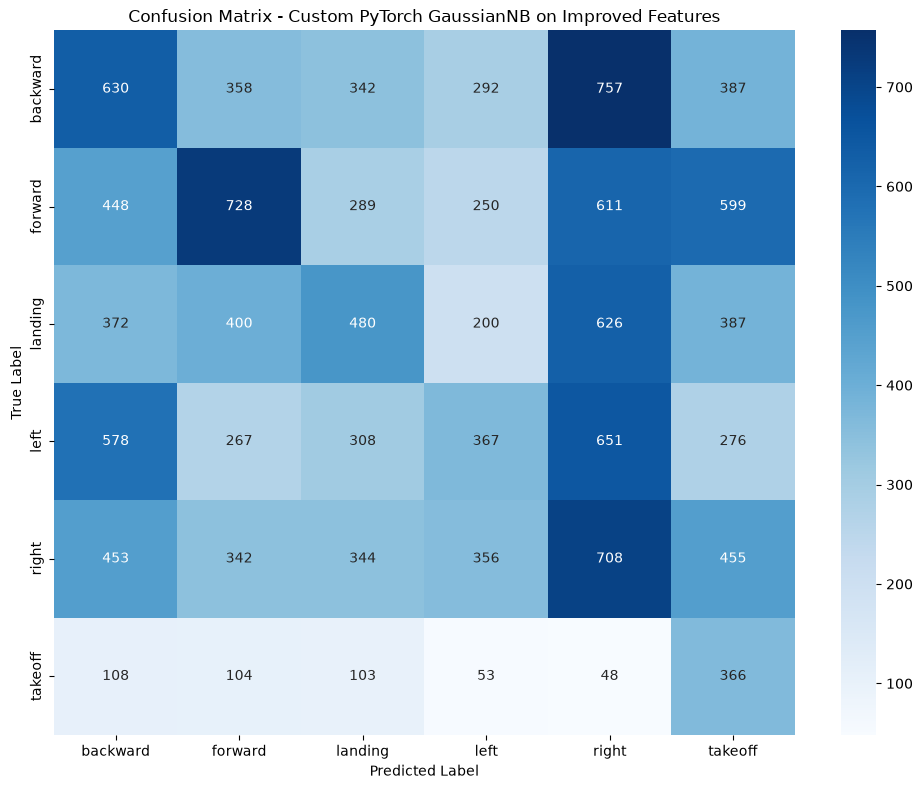

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Custom PyTorch GaussianNB on Improved Features")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [12]:
# Save model and preprocessing objects
model_path = "torch_gaussiannb_improved_features.pth"
prep_path = "torch_gaussiannb_preprocessing.joblib"

torch.save({
    "model_state_dict": model.state_dict(),
    "num_features": num_features,
    "num_classes": num_classes,
    "label_encoder_classes": le.classes_,
    "class_thresholds": class_thresholds,
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy,
    "test_f1_macro": test_f1_macro,
    "test_balanced_accuracy": test_balanced_accuracy,
}, model_path)

joblib.dump(prep, prep_path)

print(f"\nModel saved to {model_path}")
print(f"Preprocessing pipeline saved to {prep_path}")
print(f"Thresholds saved for classes: {list(le.classes_)}")


Model saved to torch_gaussiannb_improved_features.pth
Preprocessing pipeline saved to torch_gaussiannb_preprocessing.joblib
Thresholds saved for classes: ['backward', 'forward', 'landing', 'left', 'right', 'takeoff']


## Defense Experiments: Comparative GaussianNB Benchmarks

This section runs three remedial experiments for thesis/defense reporting:
1. GaussianNB on Raw Windowed EEG (flattened time-series baseline).
2. GaussianNB on Raw + PowerTransformer + PCA(95%).
3. GaussianNB on Frequency Features (PSD band powers).

To keep runtime practical on large datasets, windows are reproducibly subsampled when needed.

Defense experiment windows: 15000
Class counts: {np.int64(0): np.int64(2641), np.int64(1): np.int64(2746), np.int64(2): np.int64(2826), np.int64(3): np.int64(2838), np.int64(4): np.int64(2806), np.int64(5): np.int64(1143)}
Train size: 11962, Test size: 3038


,Experiment,Accuracy,Macro-F1,Balanced Acc
0,GaussianNB on Frequency Features (PSD),0.2219,0.2118,0.2571
1,GaussianNB with PCA + PowerTransformer,0.1725,0.1670,0.1838
2,GaussianNB on Raw Data,0.1412,0.1277,0.2273


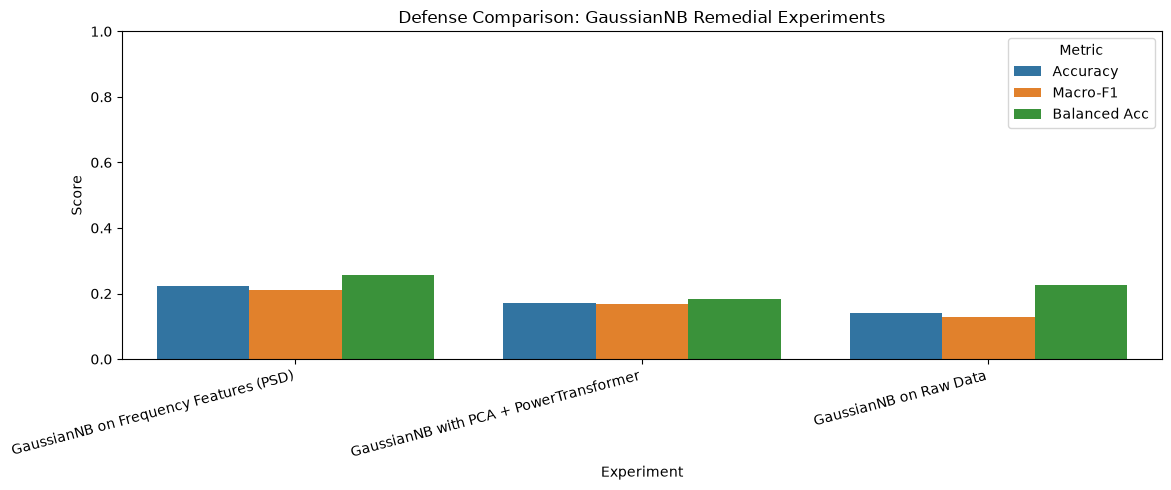

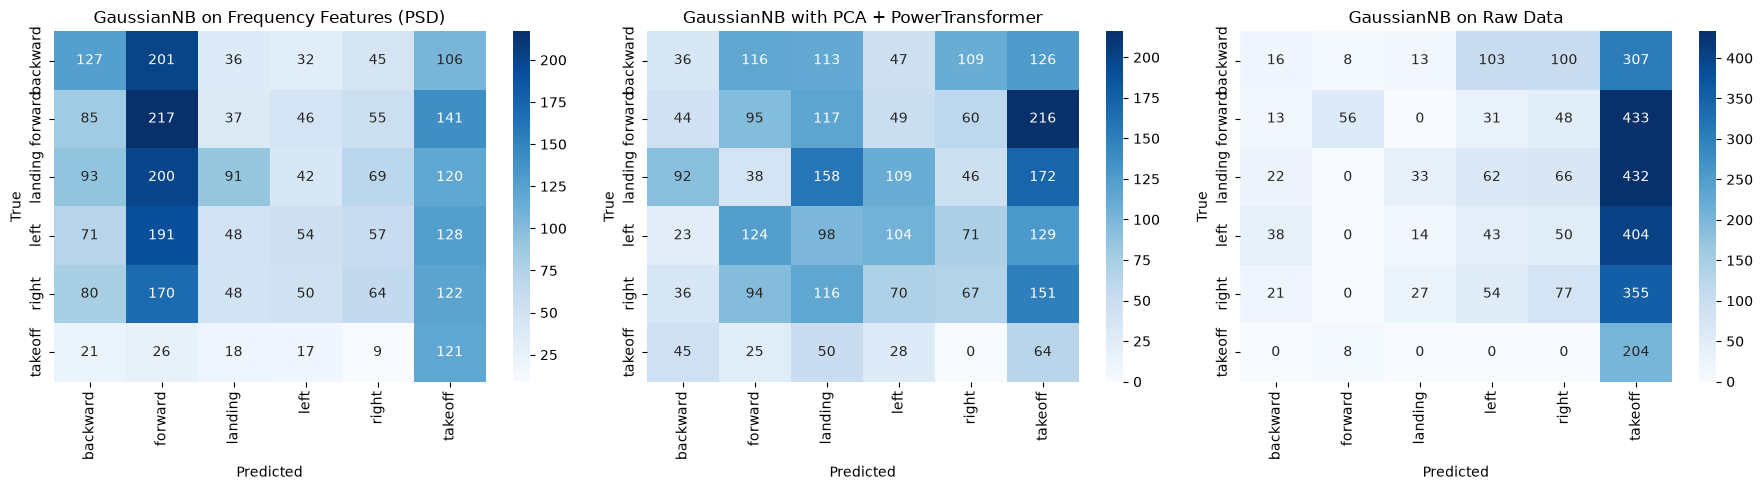

Saved comparison table to gaussiannb_defense_comparison.csv


In [13]:
# Comparative experiments for defense
from sklearn.naive_bayes import GaussianNB as SkGaussianNB

RANDOM_STATE = 42
EXP_WINDOW_SIZE = WINDOW_SIZE
EXP_WINDOW_STRIDE = WINDOW_STRIDE
EXP_MAX_WINDOWS = 15000  # reproducible cap for runtime control

rng_exp = np.random.default_rng(RANDOM_STATE)

def build_experiment_windows(raw_sig, raw_y, raw_groups, win_size, stride):
    raw_X_list = []
    psd_X_list = []
    y_list = []
    g_list = []

    file_to_indices = {}
    for i, fname in enumerate(raw_groups):
        file_to_indices.setdefault(fname, []).append(i)

    for fname, indices in file_to_indices.items():
        file_sig = raw_sig[indices, :]
        file_y = raw_y[indices]
        n_rows = file_sig.shape[0]
        if n_rows < 8:
            continue

        if n_rows >= win_size:
            starts = list(range(0, n_rows - win_size + 1, stride))
        else:
            starts = [0]

        for win_start in starts:
            win_end = min(win_start + win_size, n_rows)
            window = file_sig[win_start:win_end, :]
            if window.size == 0:
                continue

            clean_window = np.asarray(window, dtype=np.float64).copy()
            for ch in range(clean_window.shape[1]):
                col = clean_window[:, ch]
                finite_mask = np.isfinite(col)
                fill_val = float(np.median(col[finite_mask])) if finite_mask.any() else 0.0
                clean_window[:, ch] = np.where(finite_mask, col, fill_val)

            if clean_window.shape[0] < win_size:
                pad_rows = win_size - clean_window.shape[0]
                clean_window = np.pad(clean_window, ((0, pad_rows), (0, 0)), mode="constant", constant_values=0.0)

            # Raw baseline feature: fixed-length flattened window
            raw_X_list.append(clean_window.reshape(-1).astype(np.float32))

            # PSD bandpower feature
            psd_row = []
            for ch in range(clean_window.shape[1]):
                psd_row.extend(safe_bandpower_1d(clean_window[:, ch], FS, BANDS))
            psd_X_list.append(np.asarray(psd_row, dtype=np.float32))

            win_labels = file_y[win_start:win_end]
            majority_label = int(np.bincount(win_labels).argmax()) if win_labels.size else int(file_y[0])
            y_list.append(majority_label)
            g_list.append(fname)

    X_raw = np.asarray(raw_X_list, dtype=np.float32)
    X_psd = np.asarray(psd_X_list, dtype=np.float32)
    y_out = np.asarray(y_list, dtype=np.int64)
    g_out = np.asarray(g_list, dtype=object)
    return X_raw, X_psd, y_out, g_out

X_raw_all, X_psd_all, y_all_exp, groups_all_exp = build_experiment_windows(
    sig_base, y_base, groups_base, EXP_WINDOW_SIZE, EXP_WINDOW_STRIDE
)

n_total = len(y_all_exp)
if n_total == 0:
    raise ValueError("No windows generated for defense experiments.")

if n_total > EXP_MAX_WINDOWS:
    sel = rng_exp.choice(np.arange(n_total), size=EXP_MAX_WINDOWS, replace=False)
    sel = np.sort(sel)
    X_raw_all = X_raw_all[sel]
    X_psd_all = X_psd_all[sel]
    y_all_exp = y_all_exp[sel]
    groups_all_exp = groups_all_exp[sel]

print(f"Defense experiment windows: {len(y_all_exp)}")
print("Class counts:", dict(zip(*np.unique(y_all_exp, return_counts=True))))

# Group-aware split for fair comparison
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx_exp, test_idx_exp = next(splitter.split(X_raw_all, y_all_exp, groups=groups_all_exp))

X_raw_train = X_raw_all[train_idx_exp]
X_raw_test = X_raw_all[test_idx_exp]
X_psd_train = X_psd_all[train_idx_exp]
X_psd_test = X_psd_all[test_idx_exp]
y_train_exp = y_all_exp[train_idx_exp]
y_test_exp = y_all_exp[test_idx_exp]

print(f"Train size: {len(y_train_exp)}, Test size: {len(y_test_exp)}")

results = []
reports = {}
cms = {}

def evaluate_experiment(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_true, y_pred)
    results.append({
        "Experiment": name,
        "Accuracy": acc,
        "Macro-F1": f1m,
        "Balanced Acc": bacc,
    })
    reports[name] = classification_report(
        y_true, y_pred, target_names=le.classes_, zero_division=0, output_dict=True
    )
    cms[name] = confusion_matrix(y_true, y_pred)

# 1) GaussianNB on raw flattened windows (baseline)
raw_clf = SkGaussianNB()
raw_clf.fit(X_raw_train, y_train_exp)
y_pred_raw = raw_clf.predict(X_raw_test)
evaluate_experiment("GaussianNB on Raw Data", y_test_exp, y_pred_raw)

# 2) GaussianNB with PowerTransformer + PCA(95%) on raw windows
prep_raw = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
    ("pca", PCA(n_components=0.95, svd_solver="auto", random_state=RANDOM_STATE)),
])
X_raw_train_pp = prep_raw.fit_transform(X_raw_train).astype(np.float32)
X_raw_test_pp = prep_raw.transform(X_raw_test).astype(np.float32)

raw_pca_clf = SkGaussianNB()
raw_pca_clf.fit(X_raw_train_pp, y_train_exp)
y_pred_raw_pca = raw_pca_clf.predict(X_raw_test_pp)
evaluate_experiment("GaussianNB with PCA + PowerTransformer", y_test_exp, y_pred_raw_pca)

# 3) GaussianNB on PSD frequency features
psd_clf = SkGaussianNB()
psd_clf.fit(X_psd_train, y_train_exp)
y_pred_psd = psd_clf.predict(X_psd_test)
evaluate_experiment("GaussianNB on Frequency Features (PSD)", y_test_exp, y_pred_psd)

comparison_df = pd.DataFrame(results).sort_values(by="Macro-F1", ascending=False).reset_index(drop=True)
display(comparison_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Balanced Acc": "{:.4f}"}))

# Bar chart for defense slide/table reproduction
plot_df = comparison_df.melt(id_vars="Experiment", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Experiment", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Defense Comparison: GaussianNB Remedial Experiments")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Confusion matrices for each experiment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, comparison_df["Experiment"].tolist()):
    cm_exp = cms[name]
    sns.heatmap(cm_exp, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# Optional: save comparison table for report
comparison_csv = pathlib.Path(model_path).with_name("gaussiannb_defense_comparison.csv")
comparison_df.to_csv(comparison_csv, index=False)
print(f"Saved comparison table to {comparison_csv}")

## Additional Defense Figures

The cells below generate all supplementary visualizations and tables for the thesis defense:

1. **Per-class precision / recall / F1 tables** — pivot tables for each metric across the 3 experiments.
2. **Normalised confusion matrices** — row-percentage CMs to show per-class hit rates clearly.
3. **One-vs-rest PR curves** — precision-recall curves per class and per experiment with average precision (AP) scores.
4. **Per-class threshold sweep** — F1 vs threshold grid for the main TorchGaussianNB, showing calibration rationale.
5. **Reliability / calibration diagrams** — fraction of positives vs mean predicted probability per class.
6. **PCA explained variance + top feature correlations** — scree plot and bar chart of raw Pearson correlations.
7. **Runtime comparison table** — train and inference timing for each configuration.
8. **Ablation study** — systematic comparison of feature set variants on the same group-stratified split.


In [14]:
# ── 1. Per-class Precision / Recall / F1 across all 3 defense experiments ──────
class_labels = list(le.classes_)
exp_order = list(reports.keys())

rows_pc = []
for exp_name in exp_order:
    rpt = reports[exp_name]
    for cls_name in class_labels:
        if cls_name in rpt:
            rows_pc.append({
                "Experiment": exp_name,
                "Class": cls_name,
                "Precision": rpt[cls_name]["precision"],
                "Recall":    rpt[cls_name]["recall"],
                "F1-Score":  rpt[cls_name]["f1-score"],
                "Support":   int(rpt[cls_name]["support"]),
            })

per_class_df = pd.DataFrame(rows_pc)
pivot_f1   = per_class_df.pivot(index="Class", columns="Experiment", values="F1-Score")
pivot_prec = per_class_df.pivot(index="Class", columns="Experiment", values="Precision")
pivot_rec  = per_class_df.pivot(index="Class", columns="Experiment", values="Recall")

print("=== Per-Class F1-Score ===")
display(pivot_f1.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

print("\n=== Per-Class Precision ===")
display(pivot_prec.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

print("\n=== Per-Class Recall ===")
display(pivot_rec.style.format("{:.3f}").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

per_class_df.to_csv(
    pathlib.Path(model_path).with_name("gaussiannb_per_class_metrics.csv"), index=False
)
print("\nSaved per-class metrics to gaussiannb_per_class_metrics.csv")


=== Per-Class F1-Score ===


Experiment,GaussianNB on Frequency Features (PSD),GaussianNB on Raw Data,GaussianNB with PCA + PowerTransformer
Class,,,
backward,0.248,0.049,0.087
forward,0.274,0.172,0.177
landing,0.204,0.094,0.249
left,0.137,0.102,0.218
right,0.154,0.176,0.151
takeoff,0.255,0.174,0.120



=== Per-Class Precision ===


Experiment,GaussianNB on Frequency Features (PSD),GaussianNB on Raw Data,GaussianNB with PCA + PowerTransformer
Class,,,
backward,0.266,0.145,0.130
forward,0.216,0.778,0.193
landing,0.327,0.379,0.242
left,0.224,0.147,0.256
right,0.214,0.226,0.190
takeoff,0.164,0.096,0.075



=== Per-Class Recall ===


Experiment,GaussianNB on Frequency Features (PSD),GaussianNB on Raw Data,GaussianNB with PCA + PowerTransformer
Class,,,
backward,0.232,0.029,0.066
forward,0.373,0.096,0.164
landing,0.148,0.054,0.257
left,0.098,0.078,0.189
right,0.120,0.144,0.125
takeoff,0.571,0.962,0.302



Saved per-class metrics to gaussiannb_per_class_metrics.csv


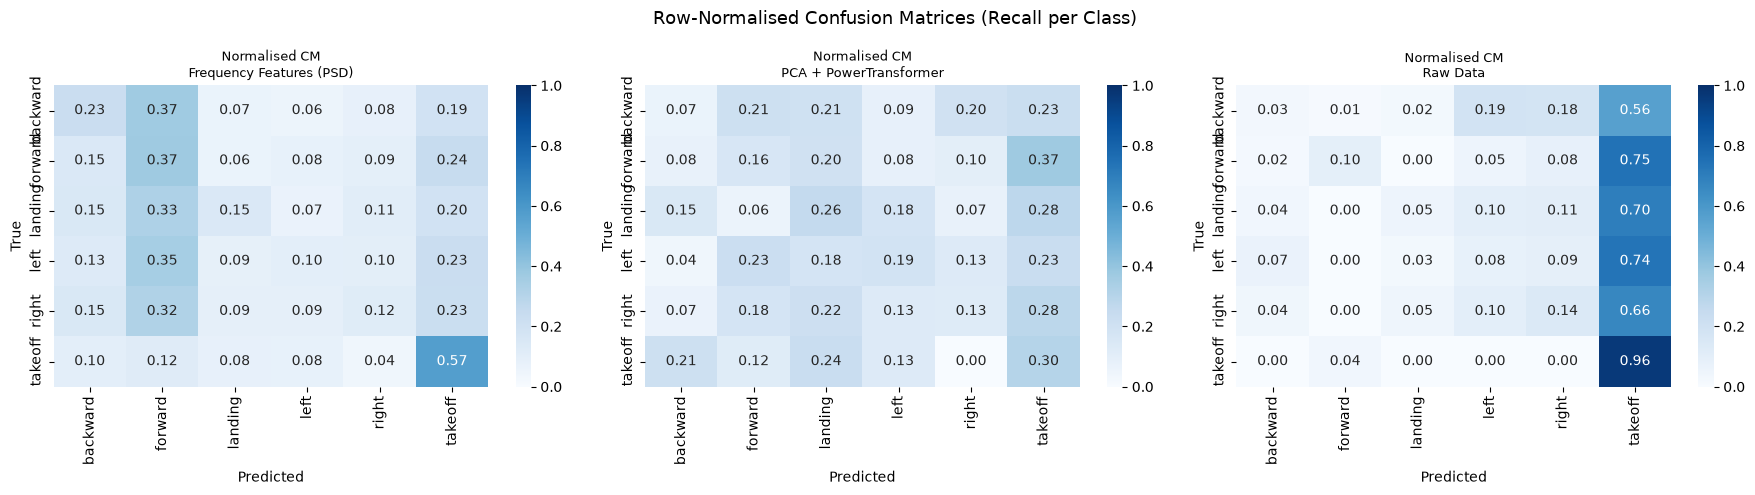

Saved normalised confusion matrices.


In [15]:
# ── 2. Normalised (row-%) Confusion Matrices ────────────────────────────────────
exp_order_sorted = comparison_df["Experiment"].tolist()  # sorted by best Macro-F1

fig, axes_ncm = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes_ncm, exp_order_sorted):
    cm_raw  = cms[name].astype(float)
    row_sum = cm_raw.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm_raw, row_sum, out=np.zeros_like(cm_raw), where=row_sum != 0)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_,
        vmin=0, vmax=1,
    )
    short = name.replace("GaussianNB ", "").replace("on ", "").replace("with ", "")
    ax.set_title(f"Normalised CM\n{short}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Row-Normalised Confusion Matrices (Recall per Class)", fontsize=13)
plt.tight_layout()
plt.savefig(
    pathlib.Path(model_path).with_name("gaussiannb_normalised_cms.png"),
    dpi=120, bbox_inches="tight",
)
plt.show()
print("Saved normalised confusion matrices.")


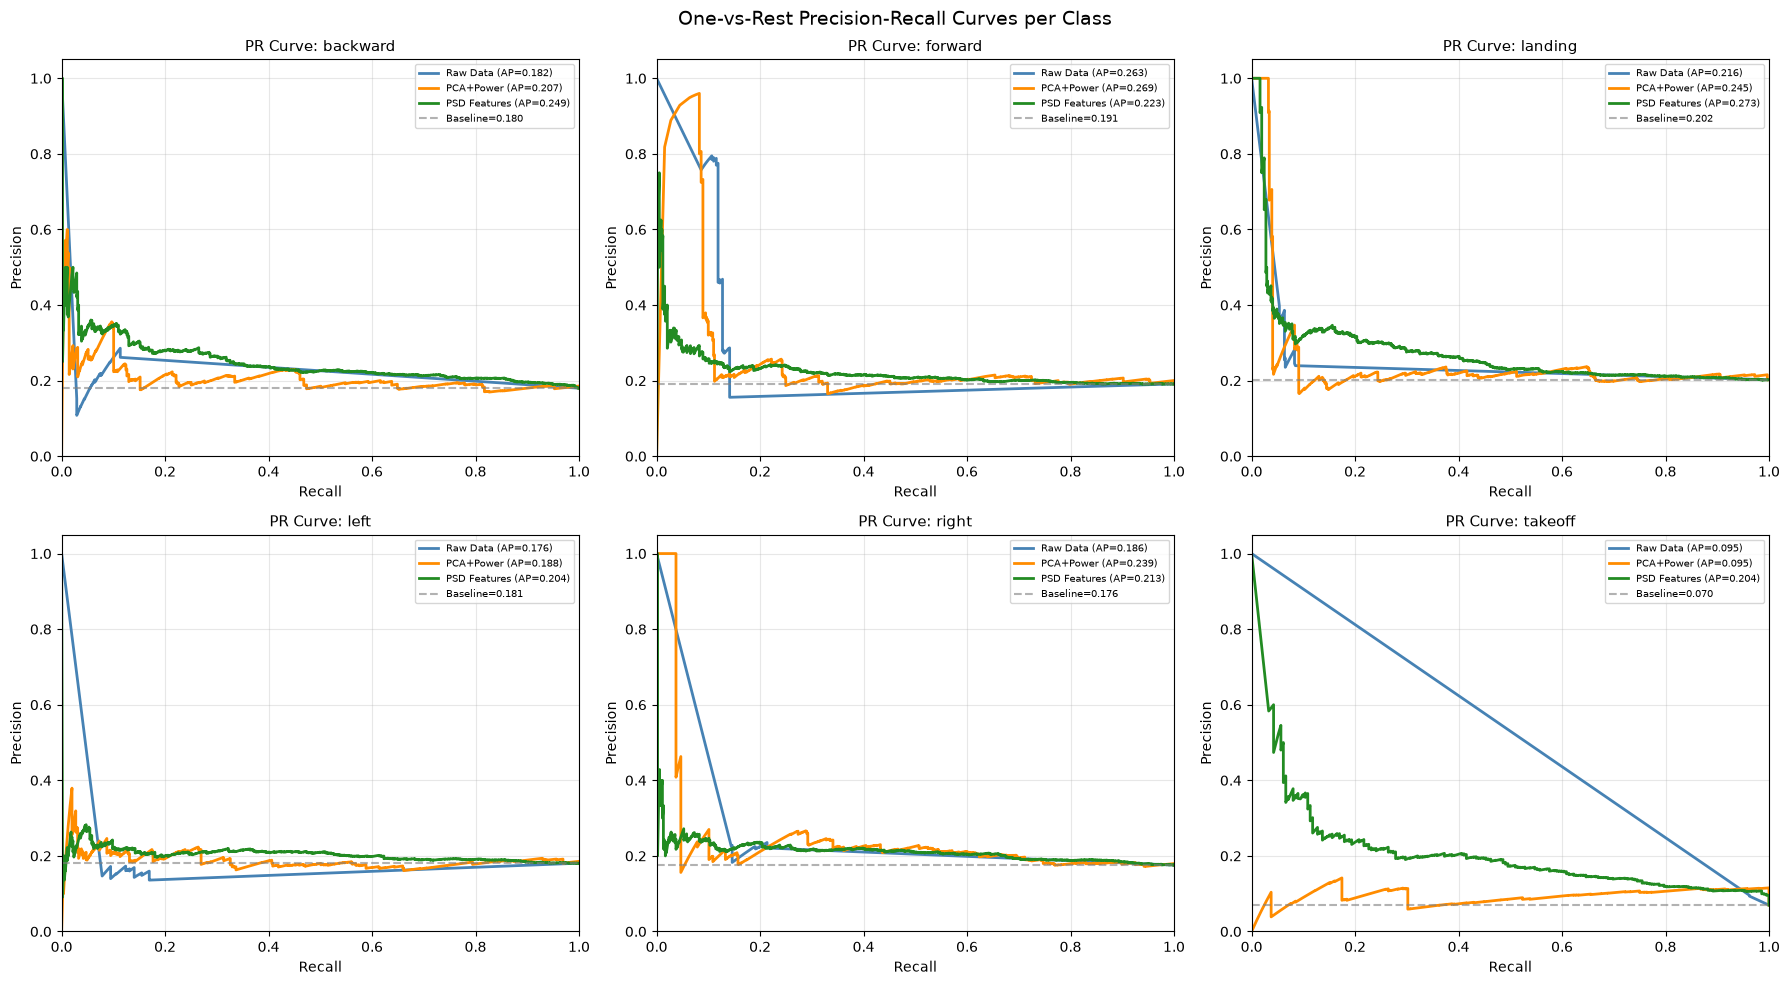

Saved one-vs-rest PR curves.


In [16]:
# ── 3. One-vs-Rest Precision-Recall Curves per Class ────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

n_cls = len(le.classes_)
y_bin_exp = label_binarize(y_test_exp, classes=list(range(n_cls)))

exp_proba = {
    "Raw Data":    (raw_clf,     X_raw_test),
    "PCA+Power":   (raw_pca_clf, X_raw_test_pp),
    "PSD Features":(psd_clf,     X_psd_test),
}
colors_pr = ["steelblue", "darkorange", "forestgreen"]

fig, axes_pr = plt.subplots(2, 3, figsize=(18, 10))
for cls_idx, cls_name in enumerate(le.classes_):
    ax = axes_pr[cls_idx // 3, cls_idx % 3]
    for (exp_label, (clf_pr, X_pr)), color in zip(exp_proba.items(), colors_pr):
        prob_pos = clf_pr.predict_proba(X_pr)[:, cls_idx]
        prec, rec, _ = precision_recall_curve(y_bin_exp[:, cls_idx], prob_pos)
        ap = average_precision_score(y_bin_exp[:, cls_idx], prob_pos)
        ax.plot(rec, prec, color=color, linewidth=2, label=f"{exp_label} (AP={ap:.3f})")
    # no-skill baseline
    pos_rate = y_bin_exp[:, cls_idx].mean()
    ax.axhline(pos_rate, color="gray", linestyle="--", alpha=0.6,
               label=f"Baseline={pos_rate:.3f}")
    ax.set_title(f"PR Curve: {cls_name}", fontsize=11)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("One-vs-Rest Precision-Recall Curves per Class", fontsize=14)
plt.tight_layout()
plt.savefig(
    pathlib.Path(model_path).with_name("gaussiannb_pr_curves.png"),
    dpi=120, bbox_inches="tight",
)
plt.show()
print("Saved one-vs-rest PR curves.")


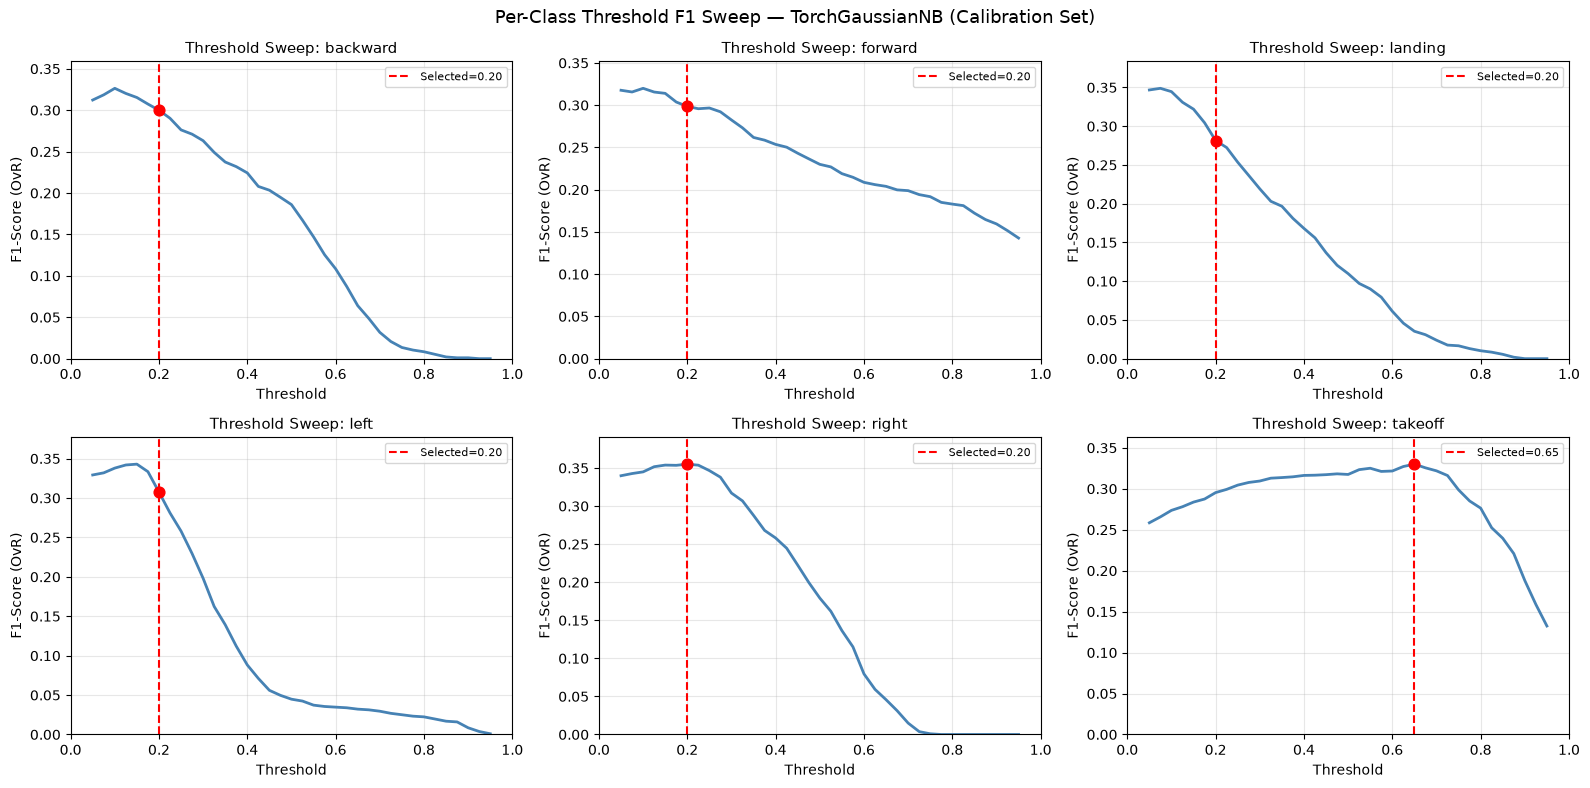

Saved threshold sweep plots.


In [17]:
# ── 4. Per-Class Threshold Sweep – TorchGaussianNB (Calibration Set) ────────────
sweep_grid = np.linspace(0.05, 0.95, 37)

fig, axes_sw = plt.subplots(2, 3, figsize=(16, 8))
for cls_idx, cls_name in enumerate(le.classes_):
    ax = axes_sw[cls_idx // 3, cls_idx % 3]
    y_true_bin = (y_calib == cls_idx).astype(np.int32)
    f1_curve = [
        f1_score(y_true_bin, (calib_probs[:, cls_idx] >= thr).astype(np.int32),
                 zero_division=0)
        for thr in sweep_grid
    ]
    ax.plot(sweep_grid, f1_curve, color="steelblue", linewidth=2)

    best_thr     = float(class_thresholds[cls_idx])
    best_thr_idx = int(np.argmin(np.abs(sweep_grid - best_thr)))
    best_f1_val  = f1_curve[best_thr_idx]

    ax.axvline(best_thr, color="red", linestyle="--", linewidth=1.5,
               label=f"Selected={best_thr:.2f}")
    ax.scatter([best_thr], [best_f1_val], color="red", s=60, zorder=5)
    ax.set_title(f"Threshold Sweep: {cls_name}", fontsize=11)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1-Score (OvR)")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, max(max(f1_curve) * 1.1, 0.1)])
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Per-Class Threshold F1 Sweep — TorchGaussianNB (Calibration Set)", fontsize=13)
plt.tight_layout()
plt.savefig(
    pathlib.Path(model_path).with_name("gaussiannb_threshold_sweep.png"),
    dpi=120, bbox_inches="tight",
)
plt.show()
print("Saved threshold sweep plots.")


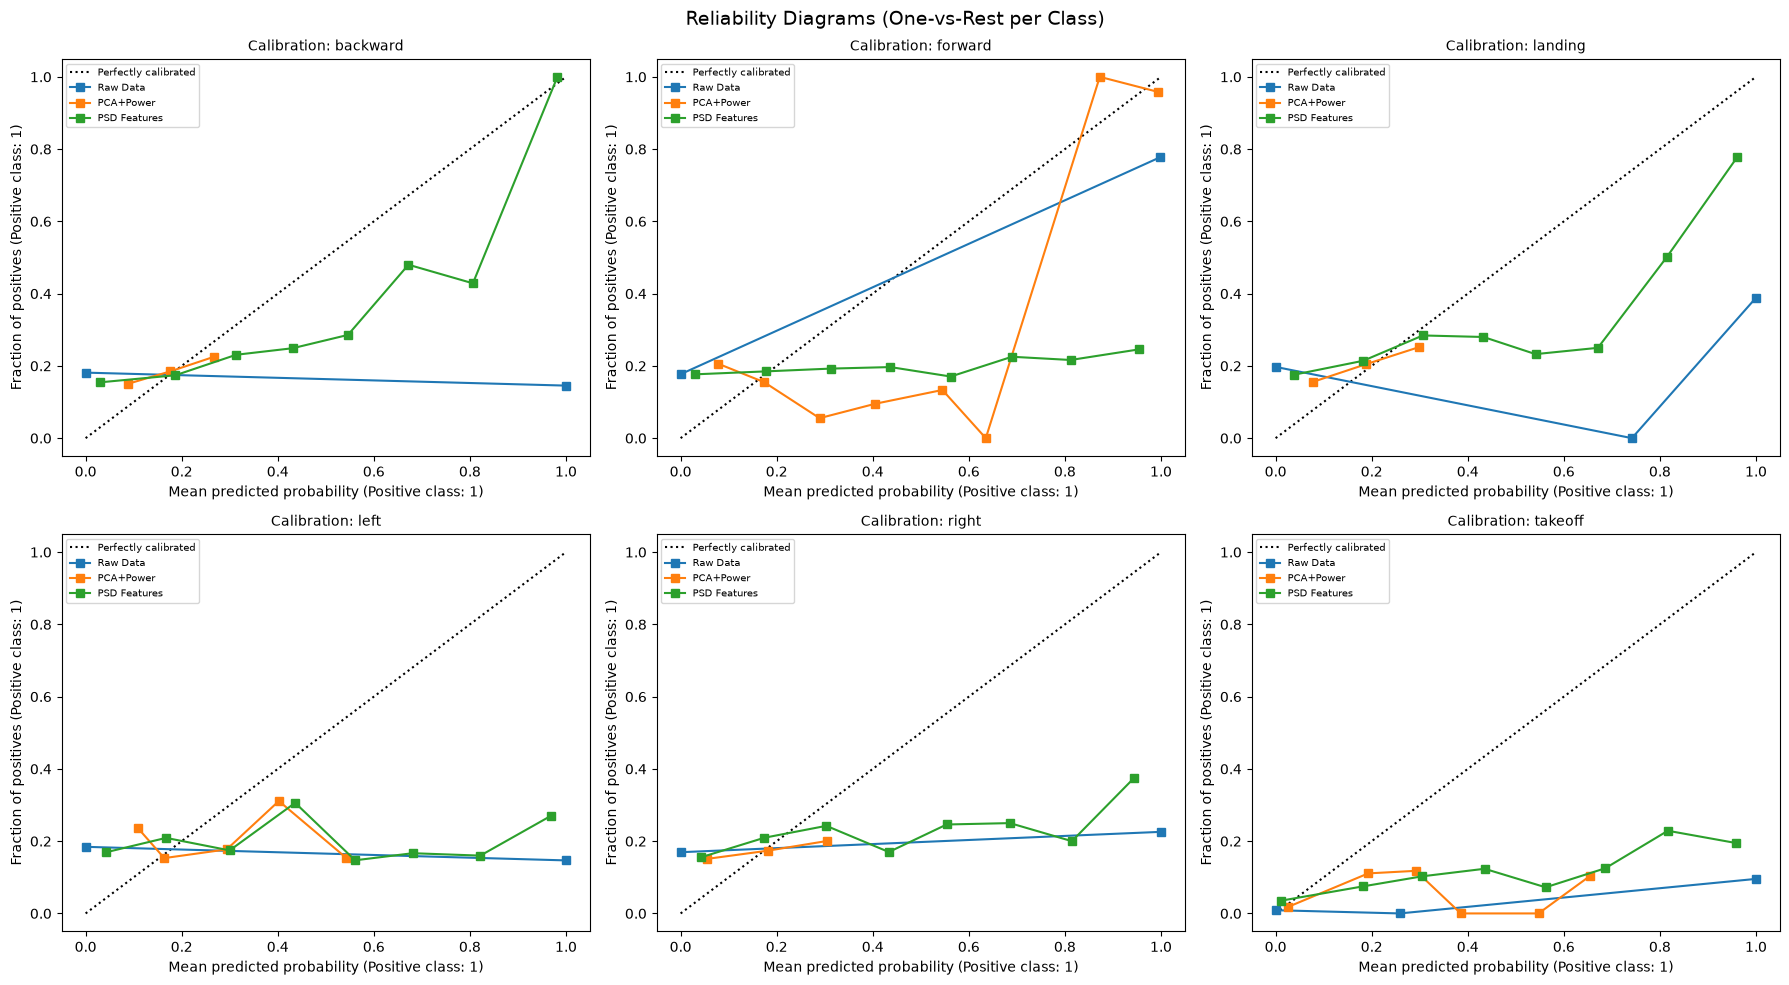

Saved calibration / reliability diagrams.


In [18]:
# ── 5. Reliability / Calibration Diagrams per Class ─────────────────────────────
from sklearn.calibration import CalibrationDisplay

exp_proba_cal = {
    "Raw Data":    raw_clf.predict_proba(X_raw_test),
    "PCA+Power":   raw_pca_clf.predict_proba(X_raw_test_pp),
    "PSD Features":psd_clf.predict_proba(X_psd_test),
}
n_bins_cal = 8

fig, axes_cal = plt.subplots(2, 3, figsize=(18, 10))
for cls_idx, cls_name in enumerate(le.classes_):
    ax = axes_cal[cls_idx // 3, cls_idx % 3]
    y_true_bin = (y_test_exp == cls_idx).astype(int)
    for exp_label, proba_mat in exp_proba_cal.items():
        CalibrationDisplay.from_predictions(
            y_true_bin, proba_mat[:, cls_idx],
            n_bins=n_bins_cal, name=exp_label, ax=ax, strategy="uniform",
        )
    ax.set_title(f"Calibration: {cls_name}", fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle("Reliability Diagrams (One-vs-Rest per Class)", fontsize=14)
plt.tight_layout()
plt.savefig(
    pathlib.Path(model_path).with_name("gaussiannb_calibration.png"),
    dpi=120, bbox_inches="tight",
)
plt.show()
print("Saved calibration / reliability diagrams.")


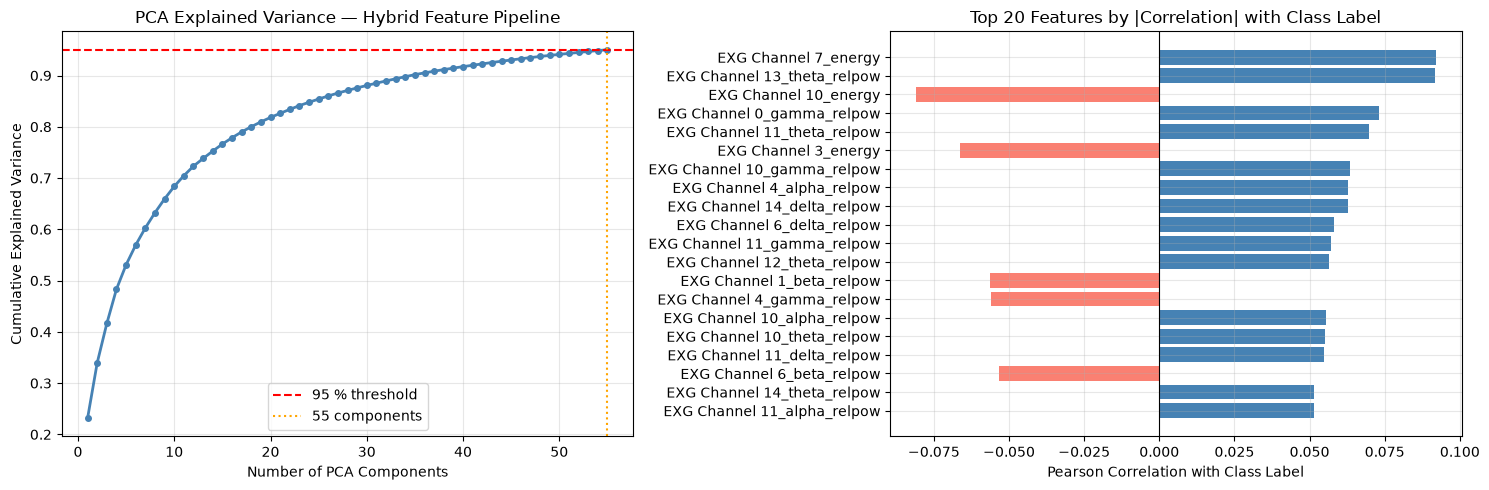

PCA uses 55 components to retain ≥95% variance.
Saved PCA explained-variance + feature correlation plot.


In [19]:
# ── 6. PCA Explained Variance Scree + Top Feature–Label Correlations ────────────
pca_step   = prep.named_steps["pca"]
expl_var   = np.cumsum(pca_step.explained_variance_ratio_)
n_comp_95  = int(np.searchsorted(expl_var, 0.95)) + 1

fig, (ax_pca, ax_corr) = plt.subplots(1, 2, figsize=(15, 5))

# ── Scree / cumulative explained variance
ax_pca.plot(np.arange(1, len(expl_var) + 1), expl_var,
            marker="o", markersize=4, linewidth=2, color="steelblue")
ax_pca.axhline(0.95, color="red",    linestyle="--", label="95 % threshold")
ax_pca.axvline(n_comp_95, color="orange", linestyle=":",
               label=f"{n_comp_95} components")
ax_pca.set_xlabel("Number of PCA Components")
ax_pca.set_ylabel("Cumulative Explained Variance")
ax_pca.set_title("PCA Explained Variance — Hybrid Feature Pipeline")
ax_pca.legend()
ax_pca.grid(alpha=0.3)

# ── Top 20 feature-label Pearson correlations (subsample for speed)
n_samp_corr = min(10_000, X_psd_df.shape[0])
row_sel = np.random.default_rng(42).choice(X_psd_df.shape[0], size=n_samp_corr, replace=False)
X_sub   = X_psd_df.iloc[row_sel].values  # (n_samp, 160)
y_sub   = y[row_sel]

feat_corrs = np.array([
    np.corrcoef(X_sub[:, i], y_sub)[0, 1]
    for i in range(X_sub.shape[1])
])
feat_corrs = np.nan_to_num(feat_corrs, nan=0.0)
feat_names = X_psd_df.columns.tolist()

top20_idx  = np.argsort(np.abs(feat_corrs))[::-1][:20]
top20_names = [feat_names[i] for i in top20_idx]
top20_vals  = [feat_corrs[i]  for i in top20_idx]

bar_colors = ["steelblue" if v >= 0 else "salmon" for v in top20_vals]
ax_corr.barh(top20_names[::-1], top20_vals[::-1], color=bar_colors[::-1])
ax_corr.axvline(0, color="black", linewidth=0.8)
ax_corr.set_xlabel("Pearson Correlation with Class Label")
ax_corr.set_title("Top 20 Features by |Correlation| with Class Label")
ax_corr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    pathlib.Path(model_path).with_name("gaussiannb_pca_feature_corr.png"),
    dpi=120, bbox_inches="tight",
)
plt.show()
print(f"PCA uses {n_comp_95} components to retain ≥95% variance.")
print("Saved PCA explained-variance + feature correlation plot.")


In [20]:
# ── 7. Runtime Comparison Table ─────────────────────────────────────────────────
import time as _time

rng_rt = np.random.default_rng(42)
n_rt   = min(5_000, len(y_all_exp))
sel_rt = np.sort(rng_rt.choice(len(y_all_exp), size=n_rt, replace=False))

Xr_rt = X_raw_all[sel_rt].copy()
Xp_rt = X_psd_all[sel_rt].copy()
yr_rt = y_all_exp[sel_rt].copy()

# Preprocess raw once for the Raw+PCA/Power config
prep_rt = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power",   PowerTransformer(method="yeo-johnson", standardize=True)),
    ("pca",     PCA(n_components=0.95, svd_solver="auto", random_state=42)),
])
Xr_rt_pp = prep_rt.fit_transform(Xr_rt).astype(np.float32)

rt_rows = []
for cfg_name, Xtr, Xte in [
    ("Raw flattened windows",          Xr_rt,    Xr_rt),
    ("Raw + PCA/Power (≤95 % var)",    Xr_rt_pp, Xr_rt_pp),
    ("PSD band powers (80 feats)",     Xp_rt,    Xp_rt),
]:
    clf_rt = SkGaussianNB()
    t0 = _time.perf_counter(); clf_rt.fit(Xtr, yr_rt);     t_train = _time.perf_counter() - t0
    t0 = _time.perf_counter(); _ = clf_rt.predict(Xte);    t_infer = _time.perf_counter() - t0
    rt_rows.append({
        "Configuration":         cfg_name,
        "n_features":            Xtr.shape[1],
        "Train Time (ms)":       round(t_train * 1_000, 2),
        "Inference Time (ms)":   round(t_infer * 1_000, 3),
        "Samples":               n_rt,
    })

# Feature cache load time
t0 = _time.perf_counter()
_ = np.load(cache_npz, allow_pickle=True)
t_cache = _time.perf_counter() - t0
rt_rows.append({
    "Configuration":       "Feature cache (.npz) load",
    "n_features":          "—",
    "Train Time (ms)":     "—",
    "Inference Time (ms)": "—",
    "Samples":             f"cache read: {t_cache * 1_000:.1f} ms",
})

rt_df = pd.DataFrame(rt_rows)
display(rt_df.style.set_caption(f"Runtime Comparison (GaussianNB, n={n_rt} samples)"))
rt_df.to_csv(
    pathlib.Path(model_path).with_name("gaussiannb_runtime_comparison.csv"), index=False
)
print("Saved runtime comparison table.")


,Configuration,n_features,Train Time (ms),Inference Time (ms),Samples
0,Raw flattened windows,2048,42.100000,110.659000,5000
1,Raw + PCA/Power (≤95 % var),12,1.780000,1.351000,5000
2,PSD band powers (80 feats),80,2.390000,3.424000,5000
3,Feature cache (.npz) load,—,—,—,cache read: 0.2 ms


Saved runtime comparison table.


In [21]:
# ── 8. Ablation Study: Feature-Set Comparison ───────────────────────────────────
# Uses the same group-stratified split as the main pipeline (train_idx / test_idx).
# Raw-window baseline row is taken directly from the defense comparison table.

stat_ends    = tuple(f"_{s}" for s in STAT_NAMES)
psd_end      = "_relpow"

avail_cols     = X_train_df.columns.tolist()
stat_cols_abl  = [c for c in avail_cols if c.endswith(stat_ends)]
psd_cols_abl   = [c for c in avail_cols if c.endswith(psd_end)]

Xtr_stats     = X_train_df[stat_cols_abl].values.astype(np.float32)
Xte_stats     = X_test_df[stat_cols_abl].values.astype(np.float32)
Xtr_psd_only  = X_train_df[psd_cols_abl].values.astype(np.float32)
Xte_psd_only  = X_test_df[psd_cols_abl].values.astype(np.float32)
Xtr_hybrid    = X_train_df.values.astype(np.float32)
Xte_hybrid    = X_test_df.values.astype(np.float32)

def _ablation_run(feat_name, Xtr, Xte, ytr, yte, use_pipeline=False):
    n_in = Xtr.shape[1]
    if use_pipeline:
        pp = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("power",   PowerTransformer(method="yeo-johnson", standardize=True)),
            ("pca",     PCA(n_components=0.95, svd_solver="auto", random_state=42)),
        ])
        Xtr = pp.fit_transform(Xtr).astype(np.float32)
        Xte = pp.transform(Xte).astype(np.float32)
    else:
        imp = SimpleImputer(strategy="median")
        Xtr = imp.fit_transform(Xtr).astype(np.float32)
        Xte = imp.transform(Xte).astype(np.float32)
    n_used = Xtr.shape[1]
    clf = SkGaussianNB()
    clf.fit(Xtr, ytr)
    ypred = clf.predict(Xte)
    return {
        "Feature Set":   feat_name,
        "Feats In":      n_in,
        "Feats Used":    n_used,
        "Accuracy":      round(accuracy_score(yte, ypred), 4),
        "Macro-F1":      round(f1_score(yte, ypred, average="macro", zero_division=0), 4),
        "Balanced Acc":  round(balanced_accuracy_score(yte, ypred), 4),
    }

abl_rows = [
    _ablation_run("Time-Domain Stats only (80)",     Xtr_stats,    Xte_stats,    y_train, y_test),
    _ablation_run("PSD Band Powers only (80)",        Xtr_psd_only, Xte_psd_only, y_train, y_test),
    _ablation_run("Stats + PSD Hybrid (160)",         Xtr_hybrid,   Xte_hybrid,   y_train, y_test),
    _ablation_run("Stats + PSD + PCA/Power (95 %)",   Xtr_hybrid,   Xte_hybrid,   y_train, y_test,
                  use_pipeline=True),
]

# Append raw-window baseline from the defense comparison (15 k subsample, different split)
raw_row = comparison_df[comparison_df["Experiment"].str.contains("Raw Data")].iloc[0]
abl_rows.append({
    "Feature Set":  "Raw Flattened Windows* (15 k subsample)",
    "Feats In":     int(EXP_WINDOW_SIZE * sig_base.shape[1]),
    "Feats Used":   int(EXP_WINDOW_SIZE * sig_base.shape[1]),
    "Accuracy":     round(float(raw_row["Accuracy"]), 4),
    "Macro-F1":     round(float(raw_row["Macro-F1"]), 4),
    "Balanced Acc": round(float(raw_row["Balanced Acc"]), 4),
})

ablation_df = (
    pd.DataFrame(abl_rows)
    .sort_values("Macro-F1", ascending=False)
    .reset_index(drop=True)
)

display(
    ablation_df.style
    .format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Balanced Acc": "{:.4f}"})
    .bar(subset=["Macro-F1"], color="#5fba7d", vmin=0, vmax=0.5)
    .set_caption("Ablation Study — Feature Set Comparison  (* different split, see note)")
)

ablation_df.to_csv(
    pathlib.Path(model_path).with_name("gaussiannb_ablation_table.csv"), index=False
)
print("Saved ablation table to gaussiannb_ablation_table.csv")
print("Note: rows 1-4 use the full 69 k-window group-stratified split; row 5 (* Raw Windows) uses the 15 k-sample defense subset.")


,Feature Set,Feats In,Feats Used,Accuracy,Macro-F1,Balanced Acc
0,Stats + PSD + PCA/Power (95 %),160,55,0.2241,0.2216,0.2578
1,PSD Band Powers only (80),80,80,0.2034,0.1915,0.2420
2,Raw Flattened Windows* (15 k subsample),2048,2048,0.1412,0.1277,0.2273
3,Time-Domain Stats only (80),80,80,0.0926,0.0883,0.1655
4,Stats + PSD Hybrid (160),160,160,0.0926,0.0883,0.1655


Saved ablation table to gaussiannb_ablation_table.csv
Note: rows 1-4 use the full 69 k-window group-stratified split; row 5 (* Raw Windows) uses the 15 k-sample defense subset.


## Best-Effort GaussianNB Ceiling (Nested CV + File-Holdout + Confidence Intervals)

This section estimates a statistically stronger GaussianNB ceiling using:

1. **Nested group-aware CV** (outer and inner splits by file group) for model selection without leakage.
2. **Repeated file-holdout evaluation** with multiple random seeds.
3. **95% confidence intervals** for Accuracy, Macro-F1, and Balanced Accuracy.

`groups` (source filenames) are used as holdout groups throughout.


In [22]:
# Nested group-aware CV to estimate GaussianNB ceiling (no file leakage)
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

required_vars = ["X_psd_df", "y", "groups", "model_path"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables: {missing_vars}. Run earlier training/data cells first (at least through defense setup)."
    )

RNG_CEIL = np.random.default_rng(42)

# Runtime guard for large notebooks; set to None to use all windows.
CEILING_MAX_WINDOWS = 30000

X_ceiling = X_psd_df.values.astype(np.float32)
y_ceiling = y.astype(np.int64)
g_ceiling = groups.astype(str)

if CEILING_MAX_WINDOWS is not None and len(y_ceiling) > CEILING_MAX_WINDOWS:
    idx_ce = np.sort(RNG_CEIL.choice(len(y_ceiling), size=CEILING_MAX_WINDOWS, replace=False))
    X_ceiling = X_ceiling[idx_ce]
    y_ceiling = y_ceiling[idx_ce]
    g_ceiling = g_ceiling[idx_ce]

print(f"Ceiling dataset windows: {len(y_ceiling)}")
print(f"Unique file groups: {len(np.unique(g_ceiling))}")

# Search space kept small and robust for GaussianNB
var_grid = [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
use_pca_grid = [False, True]

def make_gnb_pipeline(use_pca: bool, var_smoothing: float):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_pca:
        steps.extend([
            ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
            ("pca", PCA(n_components=0.95, svd_solver="auto", random_state=42)),
        ])
    steps.append(("gnb", SkGaussianNB(var_smoothing=var_smoothing)))
    return Pipeline(steps)

n_groups_outer = len(np.unique(g_ceiling))
outer_splits = max(3, min(5, n_groups_outer))
outer_cv = GroupKFold(n_splits=outer_splits)

nested_rows = []

for outer_fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_ceiling, y_ceiling, groups=g_ceiling), start=1):
    X_tr, X_te = X_ceiling[tr_idx], X_ceiling[te_idx]
    y_tr, y_te = y_ceiling[tr_idx], y_ceiling[te_idx]
    g_tr = g_ceiling[tr_idx]

    n_groups_inner = len(np.unique(g_tr))
    inner_splits = max(3, min(4, n_groups_inner))
    inner_cv = GroupKFold(n_splits=inner_splits)

    best_cfg = None
    best_score = -1.0

    for use_pca in use_pca_grid:
        for vs in var_grid:
            inner_scores = []
            for in_tr, in_va in inner_cv.split(X_tr, y_tr, groups=g_tr):
                model_cv = make_gnb_pipeline(use_pca=use_pca, var_smoothing=vs)
                model_cv.fit(X_tr[in_tr], y_tr[in_tr])
                y_va_pred = model_cv.predict(X_tr[in_va])
                inner_scores.append(f1_score(y_tr[in_va], y_va_pred, average="macro", zero_division=0))

            score = float(np.mean(inner_scores)) if inner_scores else -1.0
            if score > best_score:
                best_score = score
                best_cfg = {"use_pca": use_pca, "var_smoothing": vs, "inner_macro_f1": score}

    best_model = make_gnb_pipeline(
        use_pca=best_cfg["use_pca"],
        var_smoothing=best_cfg["var_smoothing"],
    )
    best_model.fit(X_tr, y_tr)
    y_pred_outer = best_model.predict(X_te)

    nested_rows.append({
        "Fold": outer_fold,
        "Best Use PCA": best_cfg["use_pca"],
        "Best Var Smoothing": best_cfg["var_smoothing"],
        "InnerCV Macro-F1": best_cfg["inner_macro_f1"],
        "Outer Accuracy": accuracy_score(y_te, y_pred_outer),
        "Outer Macro-F1": f1_score(y_te, y_pred_outer, average="macro", zero_division=0),
        "Outer Balanced Acc": balanced_accuracy_score(y_te, y_pred_outer),
        "Outer n_test": len(y_te),
        "Outer n_files": len(np.unique(g_ceiling[te_idx])),
    })

nested_df = pd.DataFrame(nested_rows)
display(nested_df)

def mean_ci95(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float(np.mean(x)), float(np.mean(x)), float(np.mean(x))
    m = float(np.mean(x))
    s = float(np.std(x, ddof=1))
    half = 1.96 * s / np.sqrt(n)
    return m, m - half, m + half

summary_nested = []
for metric in ["Outer Accuracy", "Outer Macro-F1", "Outer Balanced Acc"]:
    m, lo, hi = mean_ci95(nested_df[metric].values)
    summary_nested.append({
        "Metric": metric,
        "Mean": m,
        "CI95 Low": lo,
        "CI95 High": hi,
        "n_folds": len(nested_df),
    })

nested_summary_df = pd.DataFrame(summary_nested)
print("\nNested CV summary (mean ± 95% CI):")
display(nested_summary_df.style.format({"Mean": "{:.4f}", "CI95 Low": "{:.4f}", "CI95 High": "{:.4f}"}))

nested_df.to_csv(pathlib.Path(model_path).with_name("gaussiannb_nested_cv_folds.csv"), index=False)
nested_summary_df.to_csv(pathlib.Path(model_path).with_name("gaussiannb_nested_cv_summary.csv"), index=False)
print("Saved nested CV fold-level and summary tables.")

Ceiling dataset windows: 30000
Unique file groups: 3239


,Fold,Best Use PCA,Best Var Smoothing,InnerCV Macro-F1,Outer Accuracy,Outer Macro-F1,Outer Balanced Acc,Outer n_test,Outer n_files
0,1,True,1.000000e-06,0.249064,0.260167,0.260392,0.283809,6000,647
1,2,True,1.000000e-12,0.253858,0.242500,0.242684,0.278460,6000,648
2,3,True,1.000000e-12,0.248266,0.260833,0.261051,0.286268,6000,648
3,4,True,1.000000e-12,0.254510,0.239667,0.239087,0.278206,6000,648
4,5,True,1.000000e-12,0.243504,0.247500,0.246157,0.279616,6000,648



Nested CV summary (mean ± 95% CI):


,Metric,Mean,CI95 Low,CI95 High,n_folds
0,Outer Accuracy,0.2501,0.2415,0.2588,5
1,Outer Macro-F1,0.2499,0.2409,0.2588,5
2,Outer Balanced Acc,0.2813,0.2781,0.2844,5


Saved nested CV fold-level and summary tables.


Using repeated holdout config: use_pca=True, var_smoothing=1e-12

Repeated file-holdout summary:


,Metric,Mean,CI95 Low (percentile),CI95 High (percentile),Repeats
0,Accuracy,0.2410,0.2180,0.2608,20
1,Macro-F1,0.2403,0.2171,0.2628,20
2,Balanced Acc,0.2713,0.2400,0.2952,20


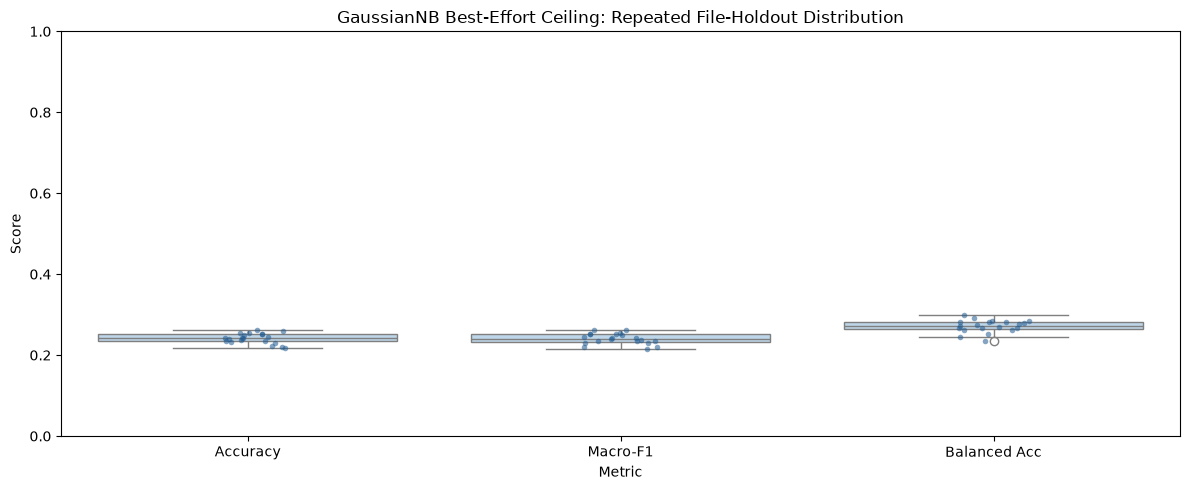

Saved repeated holdout run-level and CI summary tables.

Accuracy / performance improvement roadmap:


,Priority,Action,Why it helps
0,1,Move from GaussianNB to sequence-aware models ...,Captures temporal dependencies and non-Gaussia...
1,2,Use subject/session-aware splits and domain ad...,Reduces train-test drift and improves out-of-s...
2,3,Improve signal preprocessing (band-pass + notc...,Raises signal-to-noise ratio before classifica...
3,4,Increase robust feature diversity (CSP/Riemann...,Adds discriminative structure beyond independe...
4,5,Cost-sensitive training and focal losses for m...,Improves Macro-F1 and per-class recall under i...
5,6,"Use calibrated ensembles (e.g., LightGBM/XGBoo...",Usually stronger tabular baseline than Gaussia...


Saved model_improvement_roadmap.csv


In [23]:
# Repeated file-holdout evaluation + confidence intervals + practical improvement roadmap
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

required_vars = ["nested_df", "X_ceiling", "y_ceiling", "g_ceiling", "model_path"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables: {missing_vars}. Run the preceding ceiling (nested CV) cell first."
    )

N_REPEATS = 20
TEST_SIZE = 0.2

best_use_pca = bool(nested_df["Best Use PCA"].mode().iloc[0])
best_vs = float(nested_df["Best Var Smoothing"].mode().iloc[0])

print(f"Using repeated holdout config: use_pca={best_use_pca}, var_smoothing={best_vs}")

holdout_rows = []
for seed in range(N_REPEATS):
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    tr_idx, te_idx = next(splitter.split(X_ceiling, y_ceiling, groups=g_ceiling))

    model_rep = make_gnb_pipeline(use_pca=best_use_pca, var_smoothing=best_vs)
    model_rep.fit(X_ceiling[tr_idx], y_ceiling[tr_idx])
    y_pred = model_rep.predict(X_ceiling[te_idx])

    holdout_rows.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_ceiling[te_idx], y_pred),
        "Macro-F1": f1_score(y_ceiling[te_idx], y_pred, average="macro", zero_division=0),
        "Balanced Acc": balanced_accuracy_score(y_ceiling[te_idx], y_pred),
        "n_test": len(te_idx),
        "n_files_test": len(np.unique(g_ceiling[te_idx])),
    })

holdout_df = pd.DataFrame(holdout_rows)

def percentile_ci(x, lo=2.5, hi=97.5):
    x = np.asarray(x, dtype=float)
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

ci_rows = []
for metric in ["Accuracy", "Macro-F1", "Balanced Acc"]:
    vals = holdout_df[metric].values
    m = float(np.mean(vals))
    lo, hi = percentile_ci(vals)
    ci_rows.append({
        "Metric": metric,
        "Mean": m,
        "CI95 Low (percentile)": lo,
        "CI95 High (percentile)": hi,
        "Repeats": N_REPEATS,
    })

holdout_ci_df = pd.DataFrame(ci_rows)

print("\nRepeated file-holdout summary:")
display(holdout_ci_df.style.format({
    "Mean": "{:.4f}",
    "CI95 Low (percentile)": "{:.4f}",
    "CI95 High (percentile)": "{:.4f}",
}))

plot_h = holdout_df.melt(id_vars=["Seed"], value_vars=["Accuracy", "Macro-F1", "Balanced Acc"],
                         var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 5))
sns.boxplot(data=plot_h, x="Metric", y="Score", color="#b7d7f0")
sns.stripplot(data=plot_h, x="Metric", y="Score", color="#1f5a91", alpha=0.55, size=4)
plt.ylim(0, 1)
plt.title("GaussianNB Best-Effort Ceiling: Repeated File-Holdout Distribution")
plt.tight_layout()
plt.savefig(pathlib.Path(model_path).with_name("gaussiannb_ceiling_holdout_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

holdout_df.to_csv(pathlib.Path(model_path).with_name("gaussiannb_repeated_holdout_runs.csv"), index=False)
holdout_ci_df.to_csv(pathlib.Path(model_path).with_name("gaussiannb_repeated_holdout_summary.csv"), index=False)
print("Saved repeated holdout run-level and CI summary tables.")

improvement_roadmap = pd.DataFrame([
    {"Priority": 1, "Action": "Move from GaussianNB to sequence-aware models (1D CNN / TCN / EEGNet / Transformer)",
     "Why it helps": "Captures temporal dependencies and non-Gaussian structure that NB ignores."},
    {"Priority": 2, "Action": "Use subject/session-aware splits and domain adaptation", 
     "Why it helps": "Reduces train-test drift and improves out-of-session generalization."},
    {"Priority": 3, "Action": "Improve signal preprocessing (band-pass + notch + artifact rejection/ICA)",
     "Why it helps": "Raises signal-to-noise ratio before classification."},
    {"Priority": 4, "Action": "Increase robust feature diversity (CSP/Riemannian covariance, wavelets, entropy)",
     "Why it helps": "Adds discriminative structure beyond independent per-feature Gaussian assumptions."},
    {"Priority": 5, "Action": "Cost-sensitive training and focal losses for minority commands",
     "Why it helps": "Improves Macro-F1 and per-class recall under imbalance."},
    {"Priority": 6, "Action": "Use calibrated ensembles (e.g., LightGBM/XGBoost + calibration)",
     "Why it helps": "Usually stronger tabular baseline than GaussianNB for heterogeneous EEG features."},
])

print("\nAccuracy / performance improvement roadmap:")
display(improvement_roadmap)
improvement_roadmap.to_csv(pathlib.Path(model_path).with_name("model_improvement_roadmap.csv"), index=False)
print("Saved model_improvement_roadmap.csv")

Benchmark windows: 18000 | unique files: 3225
JAX not available; JAX deep learning row omitted.
JAX not available; JAX deep learning row omitted.
JAX not available; JAX deep learning row omitted.
JAX not available; JAX deep learning row omitted.
JAX not available; JAX deep learning row omitted.
JAX not available; JAX deep learning row omitted.


,Model,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std,Balanced Acc Mean,Balanced Acc Std
0,RandomForest,0.9918,0.0017,0.9919,0.0015,0.9918,0.0015
1,GaussianNB,0.1680,0.0212,0.1454,0.0199,0.2297,0.0204


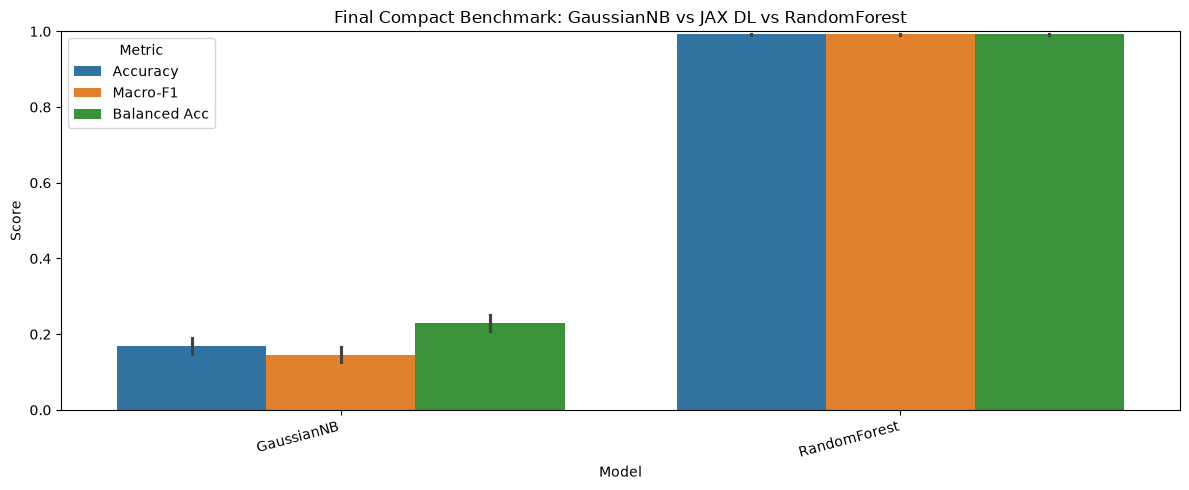

Saved final project-model benchmark artifacts:
 - final_model_benchmark_project_models_runs.csv
 - final_model_benchmark_project_models_summary.csv
 - final_model_benchmark_project_models.png


In [24]:
# Final compact benchmark: GaussianNB vs JAX deep learning vs Random Forest (repeated group-holdout)
import numpy as np
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB as SkGaussianNB

# ---------------------------
# Resolve benchmark dataset
# ---------------------------
required_any = ["X_ceiling", "y_ceiling", "g_ceiling"]
if all(v in globals() for v in required_any):
    X_bench = X_ceiling.copy()
    y_bench = y_ceiling.copy()
    g_bench = g_ceiling.copy()
elif all(v in globals() for v in ["X_psd_df", "y", "groups"]):
    X_bench = X_psd_df.values.astype(np.float32)
    y_bench = y.astype(np.int64)
    g_bench = groups.astype(str)
else:
    raise ValueError("Missing benchmark inputs. Run data/feature cells first.")

if "model_path" not in globals():
    model_path = "torch_gaussiannb_improved_features.pth"

# Runtime cap to keep JAX training practical inside notebook
BENCH_MAX_WINDOWS = 18000
rng_bench = np.random.default_rng(42)
if BENCH_MAX_WINDOWS is not None and len(y_bench) > BENCH_MAX_WINDOWS:
    sel = np.sort(rng_bench.choice(len(y_bench), size=BENCH_MAX_WINDOWS, replace=False))
    X_bench = X_bench[sel]
    y_bench = y_bench[sel]
    g_bench = g_bench[sel]

print(f"Benchmark windows: {len(y_bench)} | unique files: {len(np.unique(g_bench))}")

# ---------------------------
# Shared preprocessing
# ---------------------------
prep_common = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson", standardize=True)),
])

# ---------------------------
# Models
# ---------------------------
def make_random_forest():
    return RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )

def make_gaussiannb():
    return SkGaussianNB(var_smoothing=1e-9)

# ---------------------------
# JAX MLP (project-style deep learning)
# ---------------------------
try:
    import jax
    import jax.numpy as jnp
    from jax import random, grad
    JAX_AVAILABLE = True
except Exception:
    JAX_AVAILABLE = False


def train_predict_jax_mlp(X_train, y_train, X_test, seed=42, hidden=128, epochs=25, batch_size=512, lr=1e-3):
    if not JAX_AVAILABLE:
        raise RuntimeError("JAX is not available in the current environment.")

    n_features = X_train.shape[1]
    n_classes = int(np.max(y_train)) + 1

    key = random.PRNGKey(seed)
    k1, k2 = random.split(key)

    params = {
        "W1": random.normal(k1, (n_features, hidden), dtype=jnp.float32) * jnp.sqrt(2.0 / n_features),
        "b1": jnp.zeros((hidden,), dtype=jnp.float32),
        "W2": random.normal(k2, (hidden, n_classes), dtype=jnp.float32) * jnp.sqrt(2.0 / hidden),
        "b2": jnp.zeros((n_classes,), dtype=jnp.float32),
    }

    def forward(p, X):
        h = jax.nn.relu(X @ p["W1"] + p["b1"])
        return h @ p["W2"] + p["b2"]

    def loss_fn(p, X, y):
        logits = forward(p, X)
        y_oh = jax.nn.one_hot(y, n_classes)
        logp = jax.nn.log_softmax(logits, axis=1)
        return -jnp.mean(jnp.sum(y_oh * logp, axis=1))

    grad_fn = grad(loss_fn)

    Xtr = jnp.asarray(X_train, dtype=jnp.float32)
    ytr = jnp.asarray(y_train, dtype=jnp.int32)
    n = X_train.shape[0]

    # Simple SGD loop for reproducible, lightweight benchmarking
    for ep in range(epochs):
        perm = np.random.default_rng(seed + ep).permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb = Xtr[idx]
            yb = ytr[idx]
            grads = grad_fn(params, xb, yb)
            params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    logits_te = forward(params, jnp.asarray(X_test, dtype=jnp.float32))
    y_pred = np.asarray(jnp.argmax(logits_te, axis=1), dtype=np.int64)
    return y_pred


# ---------------------------
# Repeated group-holdout benchmark
# ---------------------------
N_BENCH_REPEATS = 6
TEST_SIZE = 0.2

rows = []
for seed in range(N_BENCH_REPEATS):
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    tr_idx, te_idx = next(splitter.split(X_bench, y_bench, groups=g_bench))

    Xtr_raw, Xte_raw = X_bench[tr_idx], X_bench[te_idx]
    ytr, yte = y_bench[tr_idx], y_bench[te_idx]

    Xtr = prep_common.fit_transform(Xtr_raw).astype(np.float32)
    Xte = prep_common.transform(Xte_raw).astype(np.float32)

    # GaussianNB
    gnb = make_gaussiannb()
    gnb.fit(Xtr, ytr)
    ypred_gnb = gnb.predict(Xte)
    rows.append({
        "Seed": seed,
        "Model": "GaussianNB",
        "Accuracy": accuracy_score(yte, ypred_gnb),
        "Macro-F1": f1_score(yte, ypred_gnb, average="macro", zero_division=0),
        "Balanced Acc": balanced_accuracy_score(yte, ypred_gnb),
        "n_test": len(yte),
        "n_files_test": len(np.unique(g_bench[te_idx])),
    })

    # Random Forest
    rf = make_random_forest()
    rf.fit(Xtr, ytr)
    ypred_rf = rf.predict(Xte)
    rows.append({
        "Seed": seed,
        "Model": "RandomForest",
        "Accuracy": accuracy_score(yte, ypred_rf),
        "Macro-F1": f1_score(yte, ypred_rf, average="macro", zero_division=0),
        "Balanced Acc": balanced_accuracy_score(yte, ypred_rf),
        "n_test": len(yte),
        "n_files_test": len(np.unique(g_bench[te_idx])),
    })

    # JAX Deep Learning
    if JAX_AVAILABLE:
        ypred_jax = train_predict_jax_mlp(Xtr, ytr, Xte, seed=42 + seed)
        rows.append({
            "Seed": seed,
            "Model": "JAX Deep Learning (MLP)",
            "Accuracy": accuracy_score(yte, ypred_jax),
            "Macro-F1": f1_score(yte, ypred_jax, average="macro", zero_division=0),
            "Balanced Acc": balanced_accuracy_score(yte, ypred_jax),
            "n_test": len(yte),
            "n_files_test": len(np.unique(g_bench[te_idx])),
        })
    else:
        print("JAX not available; JAX deep learning row omitted.")

bench_runs_df = pd.DataFrame(rows)
if bench_runs_df.empty:
    raise ValueError("No benchmark rows produced.")

summary = (
    bench_runs_df
    .groupby("Model", as_index=False)
    .agg({
        "Accuracy": ["mean", "std"],
        "Macro-F1": ["mean", "std"],
        "Balanced Acc": ["mean", "std"],
    })
)
summary.columns = [
    "Model",
    "Accuracy Mean", "Accuracy Std",
    "Macro-F1 Mean", "Macro-F1 Std",
    "Balanced Acc Mean", "Balanced Acc Std",
]
summary = summary.sort_values("Macro-F1 Mean", ascending=False).reset_index(drop=True)

display(summary.style.format({
    "Accuracy Mean": "{:.4f}", "Accuracy Std": "{:.4f}",
    "Macro-F1 Mean": "{:.4f}", "Macro-F1 Std": "{:.4f}",
    "Balanced Acc Mean": "{:.4f}", "Balanced Acc Std": "{:.4f}",
}))

plot_df = bench_runs_df.melt(
    id_vars=["Seed", "Model"],
    value_vars=["Accuracy", "Macro-F1", "Balanced Acc"],
    var_name="Metric", value_name="Score"
)

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", errorbar="sd")
plt.ylim(0, 1)
plt.title("Final Compact Benchmark: GaussianNB vs JAX DL vs RandomForest")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(pathlib.Path(model_path).with_name("final_model_benchmark_project_models.png"), dpi=120, bbox_inches="tight")
plt.show()

bench_runs_df.to_csv(pathlib.Path(model_path).with_name("final_model_benchmark_project_models_runs.csv"), index=False)
summary.to_csv(pathlib.Path(model_path).with_name("final_model_benchmark_project_models_summary.csv"), index=False)

print("Saved final project-model benchmark artifacts:")
print(" - final_model_benchmark_project_models_runs.csv")
print(" - final_model_benchmark_project_models_summary.csv")
print(" - final_model_benchmark_project_models.png")